# 4. Sudden drift detection

### Hypothesis
Sudden political/event-driven changes produce detectable drift in news language streams.

This notebook runs the full grid of experiments:

- **feature type**: TF-IDF and sentence embeddings,
- **time aggregation**: daily and weekly,
- **stream type**: left-only, right-only, and mixed,
- **mixed-stream sampling**: raw, max-*n*-per-class-per-day, global undersampling, and split-minority-per-day.

The main signal is the **cosine distance between consecutive time-window vectors**. River detectors are then applied to this numeric distance stream.


## Experiment design

1. Load chronologically ordered political news articles.
2. Prepare three stream families:
   - left-wing sources only,
   - right-wing sources only,
   - mixed left/right sources.
3. For mixed streams, evaluate multiple sampling strategies:
   - raw mixed stream,
   - max-*n*-per-class-per-day sampling,
   - global class undersampling,
   - splitting the minority class per day.
4. Aggregate each stream into daily and weekly buckets.
5. Extract vector representations:
   - TF-IDF,
   - sentence embeddings.
6. Compute cosine distances between consecutive buckets.
7. Detect abrupt changes using:
   - Page-Hinkley,
   - KSWIN,
   - ADWIN as a baseline.
8. Compare detections with selected political events:
   - 2024-03-05  Start of campaign
   - 2024-05-30  Trump conviction
   - 2024-06-27  First presidential debate
   - 2024-07-13  Trump assassination attempt
   - 2024-07-21  Biden withdraws from race
   - 2024-08-05  Harris becomes Democratic nominee
   - 2024-09-10  Second presidential debate
   - 2024-10-01  Vice presidential debate
   - 2024-11-05  US presidential election
   - 2025-01-20  Trump inauguration


## Imports and configuration

In [1]:
%matplotlib inline

import json
import math
import random
from pathlib import Path
from datetime import timedelta
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize

from river import drift

try:
    from IPython.display import display
except ImportError:
    display = print


In [15]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Main input file.
INPUT_FILE = Path("data/news_dataset2.jsonl")

# Output root.
OUTPUT_DIR = Path("results/sudden_drift_detection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEXT_COLUMN = "text"
DATE_COLUMN = "timestamp"
LABEL_COLUMN = "label"

LABEL_NAMES = {
    0: "left",
    1: "right",
}

# Analysis period: one month before campaign start and one month after inauguration.
START_DATE = pd.Timestamp("2024-02-05")
END_DATE = pd.Timestamp("2025-02-20")

EVENTS = {
    "Start of campaign": "2024-03-05",
    "Trump conviction": "2024-05-30",
    "First presidential debate": "2024-06-27",
    "Trump assassination attempt": "2024-07-13",
    "Biden withdraws from race": "2024-07-21",
    "Harris becomes Democratic nominee": "2024-08-05",
    "Second presidential debate": "2024-09-10",
    "Vice presidential debate": "2024-10-01",
    "US presidential election": "2024-11-05",
    "Trump inauguration": "2025-01-20",
}

FEATURE_TYPES = ["tfidf", "embedding"]
TIME_WINDOWS = ["D", "W"]  # D = daily, W = weekly

# Minimum bucket size. Daily buckets naturally need a lower threshold than weekly buckets.
MIN_ARTICLES_PER_WINDOW = {
    "D": 5,
    "W": 15,
}

# Matching tolerance between an alarm and an event.
EVENT_TOLERANCE_DAYS = {
    "D": 7,
    "W": 14,
}

# Mixed-stream sampling parameters.
MAX_N_PER_CLASS_PER_DAY = 3

# Embedding settings. Weekly buckets can be very long, so they are chunked and averaged.
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
EMBEDDING_CHUNK_WORDS = 220
MAX_EMBEDDING_CHUNKS_PER_WINDOW = 8

SAVE_PLOTS = True
SHOW_PLOTS = True

# If True, stop on the first failed case. If False, save errors and continue.
FAIL_FAST = False


## Small utility helpers

In [3]:
def window_name(time_window: str) -> str:
    if time_window == "D":
        return "daily"
    if time_window == "W":
        return "weekly"
    raise ValueError("time_window must be 'D' or 'W'")


def get_window_start(series: pd.Series, time_window: str) -> pd.Series:
    if time_window == "D":
        return series.dt.floor("D")

    if time_window == "W":
        # Monday-starting weekly periods.
        return series.dt.to_period("W").apply(lambda period: period.start_time)

    raise ValueError("time_window must be 'D' or 'W'")


def safe_slug(value: str) -> str:
    return (
        str(value)
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
        .replace("__", "_")
    )


def case_output_dir(feature_type: str, time_window: str, stream_group: str | None = None) -> Path:
    base = OUTPUT_DIR / feature_type / window_name(time_window)

    if stream_group is None:
        path = base / "_global"
    else:
        path = base / safe_slug(stream_group)

    path.mkdir(parents=True, exist_ok=True)
    return path


## Data loading

In [4]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []

    if not path.exists():
        raise FileNotFoundError(
            f"Input file not found: {path}\n"
            "Check INPUT_FILE or run this notebook from the project root."
        )

    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("Input file is empty or could not be read.")

    required_columns = [DATE_COLUMN, LABEL_COLUMN, TEXT_COLUMN]
    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.copy()
    df["date"] = pd.to_datetime(df[DATE_COLUMN], errors="coerce", utc=True).dt.tz_convert(None)
    df = df.dropna(subset=["date", TEXT_COLUMN, LABEL_COLUMN])

    df = df[(df["date"] >= START_DATE) & (df["date"] <= END_DATE)]
    df = df[df[LABEL_COLUMN].isin(LABEL_NAMES.keys())]

    df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str)
    df = df[df[TEXT_COLUMN].str.strip().str.len() > 0]

    df = df.sort_values("date").reset_index(drop=True)

    if df.empty:
        raise ValueError(
            "No rows left after date/label/text filtering. "
            "Check START_DATE, END_DATE, labels, and text column."
        )

    return df


def print_dataset_overview(df: pd.DataFrame):
    print(f"Rows after filtering: {len(df):,}")
    print(f"Date range: {df['date'].min()} -> {df['date'].max()}")
    print("\nArticles per label:")
    print(df[LABEL_COLUMN].value_counts().sort_index())


## Mixed-stream sampling strategies

Left-only and right-only streams do not need class balancing. Mixed streams are created with several sampling strategies to check whether detected drift is stable or caused by class imbalance.


In [5]:
def max_n_per_class_per_day(df: pd.DataFrame, n: int = 3, seed: int = SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    selected_indices = []

    temp = df.copy()
    temp["day"] = temp["date"].dt.floor("D")

    for (_, label), group in temp.groupby(["day", LABEL_COLUMN], sort=True):
        if len(group) <= n:
            selected_indices.extend(group.index.tolist())
        else:
            selected_indices.extend(rng.choice(group.index.to_numpy(), size=n, replace=False).tolist())

    return (
        df.loc[selected_indices]
        .sort_values("date")
        .reset_index(drop=True)
    )


def global_undersample(df: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    counts = df[LABEL_COLUMN].value_counts()

    if any(label not in counts for label in LABEL_NAMES):
        return pd.DataFrame(columns=df.columns)

    min_count = int(counts.min())
    parts = []

    for label in sorted(LABEL_NAMES):
        part = (
            df[df[LABEL_COLUMN] == label]
            .sample(n=min_count, random_state=seed)
        )
        parts.append(part)

    return (
        pd.concat(parts, ignore_index=True)
        .sort_values("date")
        .reset_index(drop=True)
    )


def split_text_into_parts(text: str, parts: int) -> list[str]:
    words = str(text).split()

    if parts <= 1 or len(words) == 0:
        return [str(text)]

    base_len = len(words) // parts
    remainder = len(words) % parts
    chunks = []
    idx = 0

    for i in range(parts):
        extra = 1 if i < remainder else 0
        chunk_words = words[idx: idx + base_len + extra]
        idx += base_len + extra

        if not chunk_words:
            chunk_words = words[-1:]

        chunks.append(" ".join(chunk_words))

    return chunks


def split_minority_per_day(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    temp = df.copy()
    temp["day"] = temp["date"].dt.floor("D")

    for day, day_df in temp.groupby("day", sort=True):
        left_df = day_df[day_df[LABEL_COLUMN] == 0]
        right_df = day_df[day_df[LABEL_COLUMN] == 1]

        if left_df.empty or right_df.empty:
            continue

        if len(left_df) >= len(right_df):
            majority_df = left_df
            minority_df = right_df
        else:
            majority_df = right_df
            minority_df = left_df

        rows.extend(majority_df.drop(columns=["day"]).to_dict("records"))

        target_parts = len(majority_df)
        remaining = target_parts
        remaining_articles = len(minority_df)

        for _, item in minority_df.iterrows():
            if remaining <= 0:
                break

            parts = max(1, math.ceil(remaining / remaining_articles))
            chunks = split_text_into_parts(item[TEXT_COLUMN], parts)[:remaining]

            for chunk in chunks:
                row = item.drop(labels=["day"]).to_dict()
                row[TEXT_COLUMN] = chunk
                rows.append(row)

            remaining -= len(chunks)
            remaining_articles -= 1

    if not rows:
        return pd.DataFrame(columns=df.columns)

    return (
        pd.DataFrame(rows)
        .sort_values("date")
        .reset_index(drop=True)
    )


def build_stream_sources(raw_df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    sources = {
        "left_none": raw_df[raw_df[LABEL_COLUMN] == 0].copy(),
        "right_none": raw_df[raw_df[LABEL_COLUMN] == 1].copy(),
        "mixed_raw": raw_df.copy(),
        f"mixed_max{MAX_N_PER_CLASS_PER_DAY}_per_class_day": max_n_per_class_per_day(
            raw_df,
            n=MAX_N_PER_CLASS_PER_DAY,
            seed=SEED,
        ),
        "mixed_global_undersampled": global_undersample(raw_df, seed=SEED),
        "mixed_split_minority_day": split_minority_per_day(raw_df),
    }

    for name in sources:
        sources[name] = sources[name].sort_values("date").reset_index(drop=True)

    return sources


def print_stream_source_overview(sources: dict[str, pd.DataFrame]):
    rows = []

    for name, df in sources.items():
        rows.append({
            "stream_source": name,
            "rows": len(df),
            "left": int((df[LABEL_COLUMN] == 0).sum()) if not df.empty else 0,
            "right": int((df[LABEL_COLUMN] == 1).sum()) if not df.empty else 0,
            "start": df["date"].min() if not df.empty else pd.NaT,
            "end": df["date"].max() if not df.empty else pd.NaT,
        })

    overview = pd.DataFrame(rows)
    display(overview)
    return overview


## Time-window aggregation

In [6]:
def aggregate_source_to_windows(
    source_df: pd.DataFrame,
    stream_source: str,
    time_window: str,
) -> pd.DataFrame:
    min_articles = MIN_ARTICLES_PER_WINDOW[time_window]

    if source_df.empty:
        return pd.DataFrame()

    temp = source_df.copy()
    temp["time_window"] = get_window_start(temp["date"], time_window)

    grouped = (
        temp
        .groupby("time_window")
        .agg(
            text=(TEXT_COLUMN, lambda texts: " ".join(map(str, texts))),
            n_articles=(TEXT_COLUMN, "count"),
            left_articles=(LABEL_COLUMN, lambda x: int((x == 0).sum())),
            right_articles=(LABEL_COLUMN, lambda x: int((x == 1).sum())),
            labels=(LABEL_COLUMN, lambda x: ",".join(map(str, sorted(set(x))))),
            first_date=("date", "min"),
            last_date=("date", "max"),
        )
        .reset_index()
    )

    grouped = grouped[grouped["n_articles"] >= min_articles].copy()
    grouped = grouped.sort_values("time_window").reset_index(drop=True)

    if grouped.empty:
        return grouped

    grouped["stream_source"] = stream_source
    grouped["stream_group"] = f"{stream_source}_{window_name(time_window)}"
    grouped["time_window_code"] = time_window
    grouped["time_window_name"] = window_name(time_window)

    if stream_source.startswith("left"):
        grouped["stream_family"] = "left"
        grouped["sampling"] = "none"
    elif stream_source.startswith("right"):
        grouped["stream_family"] = "right"
        grouped["sampling"] = "none"
    else:
        grouped["stream_family"] = "mixed"
        grouped["sampling"] = stream_source.replace("mixed_", "")

    return grouped


def build_window_dataframe(
    stream_sources: dict[str, pd.DataFrame],
    time_window: str,
) -> pd.DataFrame:
    windows = []

    for stream_source, source_df in stream_sources.items():
        aggregated = aggregate_source_to_windows(
            source_df=source_df,
            stream_source=stream_source,
            time_window=time_window,
        )

        if not aggregated.empty:
            windows.append(aggregated)

    if not windows:
        return pd.DataFrame()

    return pd.concat(windows, ignore_index=True).sort_values(
        ["stream_group", "time_window"]
    ).reset_index(drop=True)


## Feature extraction

In [7]:
def build_tfidf_features(window_df: pd.DataFrame) -> tuple[np.ndarray, object]:
    # min_df=2 is useful for larger experiments, but can break on small streams.
    min_df = 2 if len(window_df) >= 10 else 1

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=10_000,
        min_df=min_df,
        max_df=0.95,
        ngram_range=(1, 2),
        norm="l2",
    )

    try:
        X = vectorizer.fit_transform(window_df[TEXT_COLUMN])
    except ValueError:
        # Fallback for very small or very sparse cases.
        vectorizer = TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=10_000,
            min_df=1,
            max_df=1.0,
            ngram_range=(1, 2),
            norm="l2",
        )
        X = vectorizer.fit_transform(window_df[TEXT_COLUMN])

    return X.toarray(), vectorizer


@lru_cache(maxsize=1)
def get_sentence_transformer_model(model_name: str = EMBEDDING_MODEL_NAME):
    from sentence_transformers import SentenceTransformer
    return SentenceTransformer(model_name)


def chunk_text_for_embeddings(
    text: str,
    chunk_words: int = EMBEDDING_CHUNK_WORDS,
    max_chunks: int = MAX_EMBEDDING_CHUNKS_PER_WINDOW,
) -> list[str]:
    words = str(text).split()

    if not words:
        return [""]

    chunks = [
        " ".join(words[i:i + chunk_words])
        for i in range(0, len(words), chunk_words)
    ]

    return chunks[:max_chunks]


def build_embedding_features(window_df: pd.DataFrame) -> tuple[np.ndarray, object]:
    model = get_sentence_transformer_model(EMBEDDING_MODEL_NAME)

    all_chunks = []
    owners = []

    for row_idx, text in enumerate(window_df[TEXT_COLUMN].tolist()):
        chunks = chunk_text_for_embeddings(text)

        for chunk in chunks:
            all_chunks.append(chunk)
            owners.append(row_idx)

    chunk_embeddings = model.encode(
        all_chunks,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,
    )

    chunk_embeddings = np.asarray(chunk_embeddings)
    n_rows = len(window_df)
    dim = chunk_embeddings.shape[1]
    X = np.zeros((n_rows, dim), dtype=np.float32)
    counts = np.zeros(n_rows, dtype=np.int32)

    for owner, emb in zip(owners, chunk_embeddings):
        X[owner] += emb
        counts[owner] += 1

    counts[counts == 0] = 1
    X = X / counts[:, None]
    X = normalize(X, norm="l2")

    return X, model


def build_features(window_df: pd.DataFrame, feature_type: str) -> tuple[np.ndarray, object]:
    if feature_type == "tfidf":
        return build_tfidf_features(window_df)

    if feature_type == "embedding":
        return build_embedding_features(window_df)

    raise ValueError("feature_type must be 'tfidf' or 'embedding'")


## Drift score stream

Each stream group is treated separately. For every consecutive pair of windows in a stream, the notebook computes:

\begin{align*}
d_t = 1 - \cos(x_{t-1}, x_t)
\end{align*}

where larger values indicate a stronger distributional change between adjacent windows.


In [8]:
def compute_cosine_drift_scores(window_df: pd.DataFrame, X: np.ndarray) -> pd.DataFrame:
    rows = []

    temp = window_df.copy().reset_index(drop=True)
    temp["row_id"] = np.arange(len(temp))

    for stream_group, group_df in temp.groupby("stream_group", sort=True):
        group_df = group_df.sort_values("time_window").reset_index(drop=True)

        if len(group_df) < 2:
            continue

        indices = group_df["row_id"].to_numpy()

        for i in range(1, len(indices)):
            prev_idx = int(indices[i - 1])
            curr_idx = int(indices[i])

            score = cosine_distances(
                X[prev_idx].reshape(1, -1),
                X[curr_idx].reshape(1, -1),
            )[0, 0]

            row = group_df.iloc[i]

            rows.append({
                "stream_group": stream_group,
                "stream_source": row["stream_source"],
                "stream_family": row["stream_family"],
                "sampling": row["sampling"],
                "time_window": pd.to_datetime(row["time_window"]),
                "time_window_code": row["time_window_code"],
                "time_window_name": row["time_window_name"],
                "drift_score": float(score),
                "n_articles": int(row["n_articles"]),
                "left_articles": int(row["left_articles"]),
                "right_articles": int(row["right_articles"]),
            })

    return pd.DataFrame(rows)


## River detectors

The detector settings are tuned for a continuous cosine-distance stream rather than a binary error stream. Page-Hinkley is set to detect upward shifts where possible.


In [9]:
def make_page_hinkley(time_window: str):
    kwargs = dict(
        min_instances=5 if time_window == "D" else 3,
        delta=0.005,
        threshold=0.15 if time_window == "D" else 0.10,
        alpha=0.999,
    )

    try:
        return drift.PageHinkley(**kwargs, mode="up")
    except TypeError:
        # Older River versions do not support the mode argument.
        return drift.PageHinkley(**kwargs)


def fresh_detectors(time_window: str) -> dict[str, object]:
    if time_window == "D":
        kswin_window = 20
        kswin_stat = 5
    else:
        kswin_window = 8
        kswin_stat = 3

    return {
        "ADWIN": drift.ADWIN(delta=0.01, clock=1),
        "PageHinkley": make_page_hinkley(time_window),
        "KSWIN": drift.KSWIN(
            alpha=0.01,
            window_size=kswin_window,
            stat_size=kswin_stat,
            seed=SEED,
        ),
    }


def is_drift_detected(detector) -> bool:
    if hasattr(detector, "drift_detected"):
        return bool(detector.drift_detected)

    if hasattr(detector, "change_detected"):
        return bool(detector.change_detected)

    return False


def run_detectors(score_df: pd.DataFrame, time_window: str) -> pd.DataFrame:
    detections = []

    if score_df.empty:
        return pd.DataFrame(columns=[
            "stream_group",
            "stream_source",
            "stream_family",
            "sampling",
            "detector",
            "time_window",
            "time_window_code",
            "time_window_name",
            "drift_score",
            "n_articles",
            "left_articles",
            "right_articles",
        ])

    for stream_group, group_df in score_df.groupby("stream_group", sort=True):
        group_df = group_df.sort_values("time_window").reset_index(drop=True)
        detectors = fresh_detectors(time_window)

        for _, row in group_df.iterrows():
            score = float(row["drift_score"])

            for detector_name, detector in detectors.items():
                detector.update(score)

                if is_drift_detected(detector):
                    detections.append({
                        "stream_group": stream_group,
                        "stream_source": row["stream_source"],
                        "stream_family": row["stream_family"],
                        "sampling": row["sampling"],
                        "detector": detector_name,
                        "time_window": pd.to_datetime(row["time_window"]),
                        "time_window_code": row["time_window_code"],
                        "time_window_name": row["time_window_name"],
                        "drift_score": score,
                        "n_articles": int(row["n_articles"]),
                        "left_articles": int(row["left_articles"]),
                        "right_articles": int(row["right_articles"]),
                    })

                    print(
                        f"[DRIFT] {stream_group} | {detector_name} | "
                        f"{pd.to_datetime(row['time_window']).date()} | score={score:.4f}"
                    )

    return pd.DataFrame(detections)


## Event matching and evaluation

In [10]:
def prepare_events(time_window: str) -> pd.DataFrame:
    rows = []

    for event_name, date_str in EVENTS.items():
        event_date = pd.to_datetime(date_str)

        if event_date < START_DATE or event_date > END_DATE:
            continue

        if time_window == "D":
            event_window = event_date.floor("D")
        elif time_window == "W":
            event_window = event_date.to_period("W").start_time
        else:
            raise ValueError("time_window must be 'D' or 'W'")

        rows.append({
            "event": event_name,
            "event_date": event_date,
            "event_window": event_window,
            "time_window_code": time_window,
            "time_window_name": window_name(time_window),
        })

    return pd.DataFrame(rows)


def evaluate_detections(
    detections_df: pd.DataFrame,
    events_df: pd.DataFrame,
    tolerance_days: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    matched_cols = [
        "feature_type",
        "stream_group",
        "stream_source",
        "stream_family",
        "sampling",
        "detector",
        "time_window",
        "time_window_code",
        "time_window_name",
        "drift_score",
        "matched_event",
        "delay_days",
        "is_true_positive",
    ]

    summary_cols = [
        "feature_type",
        "stream_group",
        "stream_source",
        "stream_family",
        "sampling",
        "detector",
        "time_window_code",
        "time_window_name",
        "detections",
        "true_positives",
        "false_positives",
        "precision_like",
        "avg_delay_days",
        "events_detected",
        "events_missed",
        "event_recall",
    ]

    if detections_df.empty:
        return pd.DataFrame(columns=matched_cols), pd.DataFrame(columns=summary_cols)

    tolerance = timedelta(days=tolerance_days)
    matched_rows = []

    for _, det in detections_df.iterrows():
        detection_window = pd.to_datetime(det["time_window"])

        matched_event = None
        best_delay_days = None

        for _, event in events_df.iterrows():
            event_date = pd.to_datetime(event["event_date"])
            diff = detection_window - event_date

            if abs(diff) <= tolerance:
                delay_days = int(diff.days)

                if best_delay_days is None or abs(delay_days) < abs(best_delay_days):
                    matched_event = event["event"]
                    best_delay_days = delay_days

        matched_rows.append({
            "feature_type": det.get("feature_type", None),
            "stream_group": det["stream_group"],
            "stream_source": det["stream_source"],
            "stream_family": det["stream_family"],
            "sampling": det["sampling"],
            "detector": det["detector"],
            "time_window": detection_window,
            "time_window_code": det["time_window_code"],
            "time_window_name": det["time_window_name"],
            "drift_score": det["drift_score"],
            "matched_event": matched_event,
            "delay_days": best_delay_days,
            "is_true_positive": matched_event is not None,
        })

    matched_df = pd.DataFrame(matched_rows)

    summary = (
        matched_df
        .groupby([
            "feature_type",
            "stream_group",
            "stream_source",
            "stream_family",
            "sampling",
            "detector",
            "time_window_code",
            "time_window_name",
        ], dropna=False)
        .agg(
            detections=("time_window", "count"),
            true_positives=("is_true_positive", "sum"),
            false_positives=("is_true_positive", lambda x: int((~x).sum())),
            avg_delay_days=("delay_days", "mean"),
        )
        .reset_index()
    )

    event_coverage_rows = []

    for keys, sub in matched_df.groupby([
        "feature_type",
        "stream_group",
        "stream_source",
        "stream_family",
        "sampling",
        "detector",
        "time_window_code",
        "time_window_name",
    ], dropna=False):
        detected_events = set(sub.dropna(subset=["matched_event"])["matched_event"])
        total_events = len(events_df)

        feature_type, stream_group, stream_source, stream_family, sampling, detector_name, tw_code, tw_name = keys

        event_coverage_rows.append({
            "feature_type": feature_type,
            "stream_group": stream_group,
            "stream_source": stream_source,
            "stream_family": stream_family,
            "sampling": sampling,
            "detector": detector_name,
            "time_window_code": tw_code,
            "time_window_name": tw_name,
            "events_detected": len(detected_events),
            "events_missed": max(0, total_events - len(detected_events)),
        })

    coverage_df = pd.DataFrame(event_coverage_rows)

    summary = summary.merge(
        coverage_df,
        on=[
            "feature_type",
            "stream_group",
            "stream_source",
            "stream_family",
            "sampling",
            "detector",
            "time_window_code",
            "time_window_name",
        ],
        how="left",
    )

    summary["precision_like"] = summary["true_positives"] / summary["detections"].replace(0, np.nan)
    summary["event_recall"] = summary["events_detected"] / len(events_df) if len(events_df) else np.nan

    return matched_df[matched_cols], summary[summary_cols]


def complete_summary_rows(
    summary_df: pd.DataFrame,
    score_df: pd.DataFrame,
    feature_type: str,
    time_window: str,
    events_df: pd.DataFrame,
) -> pd.DataFrame:
    """Add zero-detection rows so every stream/detector combination appears in summaries."""
    summary_cols = [
        "feature_type",
        "stream_group",
        "stream_source",
        "stream_family",
        "sampling",
        "detector",
        "time_window_code",
        "time_window_name",
        "detections",
        "true_positives",
        "false_positives",
        "precision_like",
        "avg_delay_days",
        "events_detected",
        "events_missed",
        "event_recall",
    ]

    metadata_cols = [
        "stream_group",
        "stream_source",
        "stream_family",
        "sampling",
        "time_window_code",
        "time_window_name",
    ]

    if score_df.empty:
        return summary_df.reindex(columns=summary_cols)

    stream_meta = (
        score_df[metadata_cols]
        .drop_duplicates()
        .sort_values("stream_group")
        .reset_index(drop=True)
    )

    detectors = list(fresh_detectors(time_window).keys())
    expected_rows = []
    total_events = len(events_df)

    for _, meta in stream_meta.iterrows():
        for detector_name in detectors:
            expected_rows.append({
                "feature_type": feature_type,
                "stream_group": meta["stream_group"],
                "stream_source": meta["stream_source"],
                "stream_family": meta["stream_family"],
                "sampling": meta["sampling"],
                "detector": detector_name,
                "time_window_code": meta["time_window_code"],
                "time_window_name": meta["time_window_name"],
                "detections": 0,
                "true_positives": 0,
                "false_positives": 0,
                "precision_like": np.nan,
                "avg_delay_days": np.nan,
                "events_detected": 0,
                "events_missed": total_events,
                "event_recall": 0.0 if total_events else np.nan,
            })

    expected_df = pd.DataFrame(expected_rows)

    if summary_df.empty:
        return expected_df[summary_cols]

    key_cols = [
        "feature_type",
        "stream_group",
        "stream_source",
        "stream_family",
        "sampling",
        "detector",
        "time_window_code",
        "time_window_name",
    ]

    completed = expected_df.set_index(key_cols)
    actual = summary_df.set_index(key_cols)

    completed.update(actual)

    return completed.reset_index()[summary_cols]


## Plotting

In [11]:
def plot_drift_timeline(
    score_df: pd.DataFrame,
    detections_df: pd.DataFrame,
    events_df: pd.DataFrame,
    feature_type: str,
    time_window: str,
    stream_group: str,
    output_dir: Path,
):
    sub_scores = score_df[score_df["stream_group"] == stream_group].sort_values("time_window")

    if sub_scores.empty:
        print(f"No scores to plot for stream: {stream_group}")
        return

    plt.figure(figsize=(16, 7))

    plt.plot(
        sub_scores["time_window"],
        sub_scores["drift_score"],
        marker="o",
        linewidth=1.3,
        label="Cosine drift score",
    )

    y_max = float(sub_scores["drift_score"].max())
    y_text = y_max if y_max > 0 else 1.0

    for idx, event in events_df.reset_index(drop=True).iterrows():
        event_date = pd.to_datetime(event["event_date"])

        plt.axvline(
            event_date,
            linestyle="-",
            linewidth=1.0,
            alpha=0.35,
        )

        # Alternate labels a bit to reduce overlap.
        y_pos = y_text * (0.98 - 0.08 * (idx % 3))
        plt.text(
            event_date,
            y_pos,
            event["event"],
            rotation=90,
            verticalalignment="top",
            fontsize=8,
            alpha=0.85,
        )

    sub_det = detections_df[detections_df["stream_group"] == stream_group]

    detector_markers = {
        "ADWIN": "o",
        "PageHinkley": "s",
        "KSWIN": "^",
    }

    if not sub_det.empty:
        for detector_name, sub in sub_det.groupby("detector"):
            plt.scatter(
                sub["time_window"],
                sub["drift_score"],
                s=90,
                marker=detector_markers.get(detector_name, "x"),
                label=f"{detector_name} alarm",
                zorder=5,
            )

            for _, row in sub.iterrows():
                plt.axvline(
                    pd.to_datetime(row["time_window"]),
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.55,
                )

    plt.title(
        f"Sudden drift detection | {stream_group} | {feature_type} | {window_name(time_window)}",
        fontsize=15,
        fontweight="bold",
    )
    plt.xlabel("Time")
    plt.ylabel("Cosine distance from previous window")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="best")
    plt.tight_layout()

    if SAVE_PLOTS:
        output_path = output_dir / "plot.png"
        plt.savefig(output_path, dpi=200)
        print(f"Saved plot: {output_path}")

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()


## Saving results

In [12]:
def save_case_results(
    feature_type: str,
    time_window: str,
    window_df: pd.DataFrame,
    score_df: pd.DataFrame,
    detections_df: pd.DataFrame,
    matched_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    events_df: pd.DataFrame,
):
    global_dir = case_output_dir(feature_type, time_window)

    window_export = window_df.drop(columns=[TEXT_COLUMN], errors="ignore")
    window_export.to_csv(global_dir / "windows.csv", index=False)
    score_df.to_csv(global_dir / "all_scores.csv", index=False)
    detections_df.to_csv(global_dir / "all_detections.csv", index=False)
    matched_df.to_csv(global_dir / "all_matched.csv", index=False)
    summary_df.to_csv(global_dir / "all_summary.csv", index=False)
    events_df.to_csv(global_dir / "events.csv", index=False)

    for stream_group in sorted(window_df["stream_group"].unique()):
        out_dir = case_output_dir(feature_type, time_window, stream_group)

        window_export[window_export["stream_group"] == stream_group].to_csv(out_dir / "windows.csv", index=False)
        score_df[score_df["stream_group"] == stream_group].to_csv(out_dir / "scores.csv", index=False)
        detections_df[detections_df["stream_group"] == stream_group].to_csv(out_dir / "detections.csv", index=False)
        matched_df[matched_df["stream_group"] == stream_group].to_csv(out_dir / "matched.csv", index=False)
        summary_df[summary_df["stream_group"] == stream_group].to_csv(out_dir / "summary.csv", index=False)

    print(f"Saved case results: {global_dir}")


def save_master_results(
    all_scores: pd.DataFrame,
    all_detections: pd.DataFrame,
    all_matched: pd.DataFrame,
    all_summary: pd.DataFrame,
    errors: pd.DataFrame | None = None,
):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    all_scores.to_csv(OUTPUT_DIR / "master_scores.csv", index=False)
    all_detections.to_csv(OUTPUT_DIR / "master_detections.csv", index=False)
    all_matched.to_csv(OUTPUT_DIR / "master_matched.csv", index=False)
    all_summary.to_csv(OUTPUT_DIR / "master_summary.csv", index=False)

    if errors is not None and not errors.empty:
        errors.to_csv(OUTPUT_DIR / "errors.csv", index=False)

    print(f"Saved master results in: {OUTPUT_DIR}")


## Experiment runner

In [13]:
def run_single_case(
    stream_sources: dict[str, pd.DataFrame],
    feature_type: str,
    time_window: str,
):
    print("=" * 90)
    print(f"Running case: feature={feature_type} | window={window_name(time_window)}")
    print("=" * 90)

    window_df = build_window_dataframe(stream_sources, time_window=time_window)

    if window_df.empty:
        raise ValueError(f"No windows created for time_window={time_window}")

    print(f"Number of aggregated windows: {len(window_df):,}")
    print("Windows per stream:")
    display(
        window_df
        .groupby(["stream_group", "stream_family", "sampling"])
        .agg(
            windows=("time_window", "count"),
            total_articles=("n_articles", "sum"),
            avg_articles=("n_articles", "mean"),
        )
        .reset_index()
        .sort_values(["stream_family", "stream_group"])
    )

    print(f"Building {feature_type} features...")
    X, feature_model = build_features(window_df, feature_type=feature_type)
    print(f"Feature matrix shape: {X.shape}")

    print("Computing cosine drift scores...")
    score_df = compute_cosine_drift_scores(window_df, X)
    score_df["feature_type"] = feature_type

    print(f"Number of drift-score observations: {len(score_df):,}")

    print("Running River detectors...")
    detections_df = run_detectors(score_df, time_window=time_window)
    if not detections_df.empty:
        detections_df["feature_type"] = feature_type
    else:
        detections_df = pd.DataFrame(columns=[
            "feature_type",
            "stream_group",
            "stream_source",
            "stream_family",
            "sampling",
            "detector",
            "time_window",
            "time_window_code",
            "time_window_name",
            "drift_score",
            "n_articles",
            "left_articles",
            "right_articles",
        ])

    print("Preparing event table...")
    events_df = prepare_events(time_window=time_window)

    print("Evaluating detections...")
    matched_df, summary_df = evaluate_detections(
        detections_df=detections_df,
        events_df=events_df,
        tolerance_days=EVENT_TOLERANCE_DAYS[time_window],
    )

    summary_df = complete_summary_rows(
        summary_df=summary_df,
        score_df=score_df,
        feature_type=feature_type,
        time_window=time_window,
        events_df=events_df,
    )

    print("Summary:")
    display(summary_df.sort_values(
        ["event_recall", "precision_like", "true_positives"],
        ascending=False,
        na_position="last",
    ))

    print("Saving case results...")
    save_case_results(
        feature_type=feature_type,
        time_window=time_window,
        window_df=window_df,
        score_df=score_df,
        detections_df=detections_df,
        matched_df=matched_df,
        summary_df=summary_df,
        events_df=events_df,
    )

    print("Creating plots...")
    for stream_group in sorted(window_df["stream_group"].unique()):
        out_dir = case_output_dir(feature_type, time_window, stream_group)
        plot_drift_timeline(
            score_df=score_df,
            detections_df=detections_df,
            events_df=events_df,
            feature_type=feature_type,
            time_window=time_window,
            stream_group=stream_group,
            output_dir=out_dir,
        )

    return {
        "feature_type": feature_type,
        "time_window": time_window,
        "window_df": window_df,
        "score_df": score_df,
        "detections_df": detections_df,
        "matched_df": matched_df,
        "summary_df": summary_df,
        "events_df": events_df,
    }


def run_all_experiments(
    raw_df: pd.DataFrame,
    feature_types: list[str] = FEATURE_TYPES,
    time_windows: list[str] = TIME_WINDOWS,
):
    stream_sources = build_stream_sources(raw_df)

    print("Stream source overview:")
    source_overview = print_stream_source_overview(stream_sources)
    source_overview.to_csv(OUTPUT_DIR / "stream_source_overview.csv", index=False)

    all_scores = []
    all_detections = []
    all_matched = []
    all_summary = []
    errors = []

    for time_window in time_windows:
        for feature_type in feature_types:
            try:
                result = run_single_case(
                    stream_sources=stream_sources,
                    feature_type=feature_type,
                    time_window=time_window,
                )

                all_scores.append(result["score_df"])
                all_detections.append(result["detections_df"])
                all_matched.append(result["matched_df"])
                all_summary.append(result["summary_df"])

            except Exception as exc:
                error_row = {
                    "feature_type": feature_type,
                    "time_window_code": time_window,
                    "time_window_name": window_name(time_window),
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                }
                errors.append(error_row)

                print(f"[ERROR] {error_row}")

                if FAIL_FAST:
                    raise

    all_scores_df = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()
    all_detections_df = pd.concat(all_detections, ignore_index=True) if all_detections else pd.DataFrame()
    all_matched_df = pd.concat(all_matched, ignore_index=True) if all_matched else pd.DataFrame()
    all_summary_df = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()
    errors_df = pd.DataFrame(errors)

    save_master_results(
        all_scores=all_scores_df,
        all_detections=all_detections_df,
        all_matched=all_matched_df,
        all_summary=all_summary_df,
        errors=errors_df,
    )

    return all_scores_df, all_detections_df, all_matched_df, all_summary_df, errors_df


## Run the full analysis

This cell performs all combinations:

- TF-IDF + daily,
- TF-IDF + weekly,
- embeddings + daily,
- embeddings + weekly,

and for each case it analyzes left-only, right-only, and all mixed sampling streams.


Rows after filtering: 6,543
Date range: 2024-02-05 00:15:00 -> 2025-02-19 23:15:00

Articles per label:
label
0     923
1    5620
Name: count, dtype: int64
Stream source overview:


,stream_source,rows,left,right,start,end
0,left_none,923,923,0,2024-02-06 02:45:00,2025-02-19 22:15:00
1,right_none,5620,0,5620,2024-02-05 00:15:00,2025-02-19 23:15:00
2,mixed_raw,6543,923,5620,2024-02-05 00:15:00,2025-02-19 23:15:00
3,mixed_max3_per_class_day,1748,680,1068,2024-02-05 00:15:00,2025-02-19 23:15:00
4,mixed_global_undersampled,1846,923,923,2024-02-05 06:00:00,2025-02-19 23:15:00
5,mixed_split_minority_day,8926,4463,4463,2024-02-06 02:45:00,2025-02-19 23:15:00


Running case: feature=tfidf | window=daily
Number of aggregated windows: 1,421
Windows per stream:


,stream_group,stream_family,sampling,windows,total_articles,avg_articles
0,left_none_daily,left,none,70,418,5.971429
1,mixed_global_undersampled_daily,mixed,global_undersampled,180,1352,7.511111
2,mixed_max3_per_class_day_daily,mixed,max3_per_class_day,201,1151,5.726368
3,mixed_raw_daily,mixed,raw,355,6476,18.242254
4,mixed_split_minority_day_daily,mixed,split_minority_day,277,8920,32.202166
5,right_none_daily,right,none,338,5556,16.437870


Building tfidf features...
Feature matrix shape: (1421, 10000)
Computing cosine drift scores...
Number of drift-score observations: 1,415
Running River detectors...
[DRIFT] left_none_daily | PageHinkley | 2024-07-16 | score=0.9122
[DRIFT] left_none_daily | PageHinkley | 2024-08-07 | score=0.8567
[DRIFT] left_none_daily | PageHinkley | 2024-12-09 | score=0.8799
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-02-22 | score=0.9140
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-04-17 | score=0.9163
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-05-03 | score=0.8662
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-05-10 | score=0.9711
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-05-28 | score=0.9479
[DRIFT] mixed_global_undersampled_daily | KSWIN | 2024-06-04 | score=0.8722
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-07-30 | score=0.9582
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-08-13 | 

,feature_type,stream_group,stream_source,stream_family,sampling,detector,time_window_code,time_window_name,detections,true_positives,false_positives,precision_like,avg_delay_days,events_detected,events_missed,event_recall
10,tfidf,mixed_raw_daily,mixed_raw,mixed,raw,PageHinkley,D,daily,33,14,19,0.424242,0.928571,10,0,1.0
16,tfidf,right_none_daily,right_none,right,none,PageHinkley,D,daily,31,12,19,0.387097,-0.666667,8,2,0.8
13,tfidf,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,D,daily,24,8,16,0.333333,1.625000,8,2,0.8
11,tfidf,mixed_raw_daily,mixed_raw,mixed,raw,KSWIN,D,daily,7,4,3,0.571429,1.750000,4,6,0.4
7,tfidf,mixed_max3_per_class_day_daily,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,D,daily,9,3,6,0.333333,4.000000,3,7,0.3
4,tfidf,mixed_global_undersampled_daily,mixed_global_undersampled,mixed,global_undersampled,PageHinkley,D,daily,11,3,8,0.272727,-2.000000,3,7,0.3
1,tfidf,left_none_daily,left_none,left,none,PageHinkley,D,daily,3,2,1,0.666667,2.500000,2,8,0.2
14,tfidf,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,KSWIN,D,daily,1,1,0,1.000000,0.000000,1,9,0.1
5,tfidf,mixed_global_undersampled_daily,mixed_global_undersampled,mixed,global_undersampled,KSWIN,D,daily,2,1,1,0.500000,5.000000,1,9,0.1
8,tfidf,mixed_max3_per_class_day_daily,mixed_max3_per_class_day,mixed,max3_per_class_day,KSWIN,D,daily,3,1,2,0.333333,-7.000000,1,9,0.1


Saving case results...
Saved case results: results\sudden_drift_detection\tfidf\daily\_global
Creating plots...
Saved plot: results\sudden_drift_detection\tfidf\daily\left_none_daily\plot.png


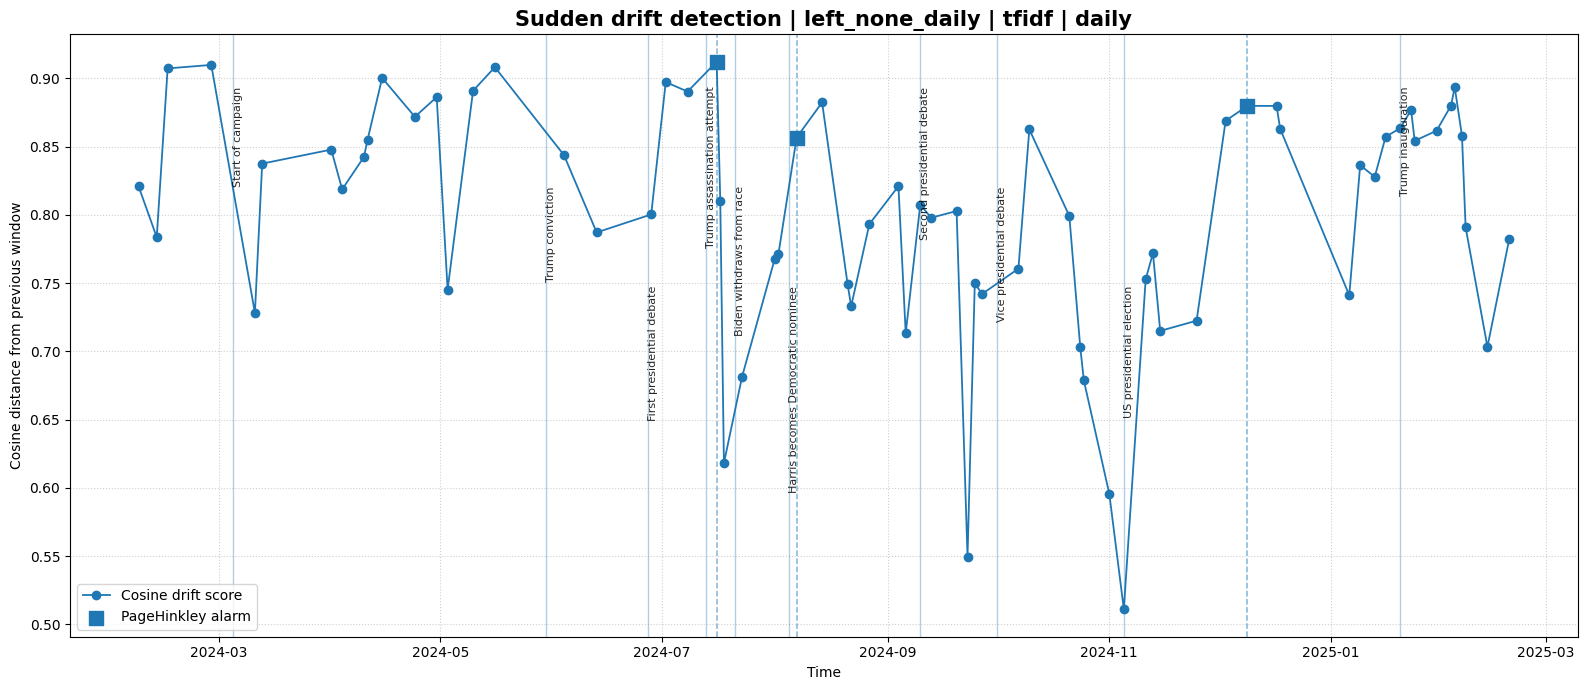

Saved plot: results\sudden_drift_detection\tfidf\daily\mixed_global_undersampled_daily\plot.png


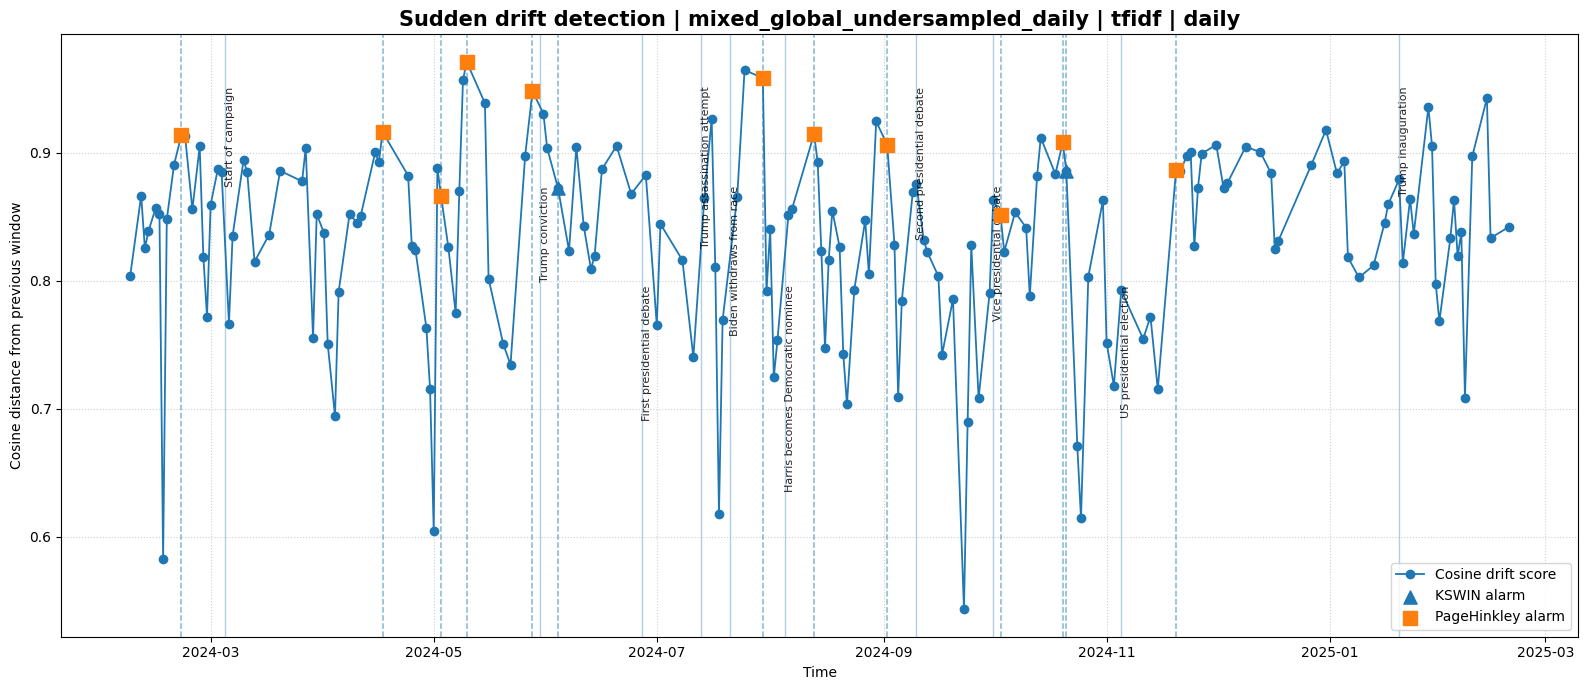

Saved plot: results\sudden_drift_detection\tfidf\daily\mixed_max3_per_class_day_daily\plot.png


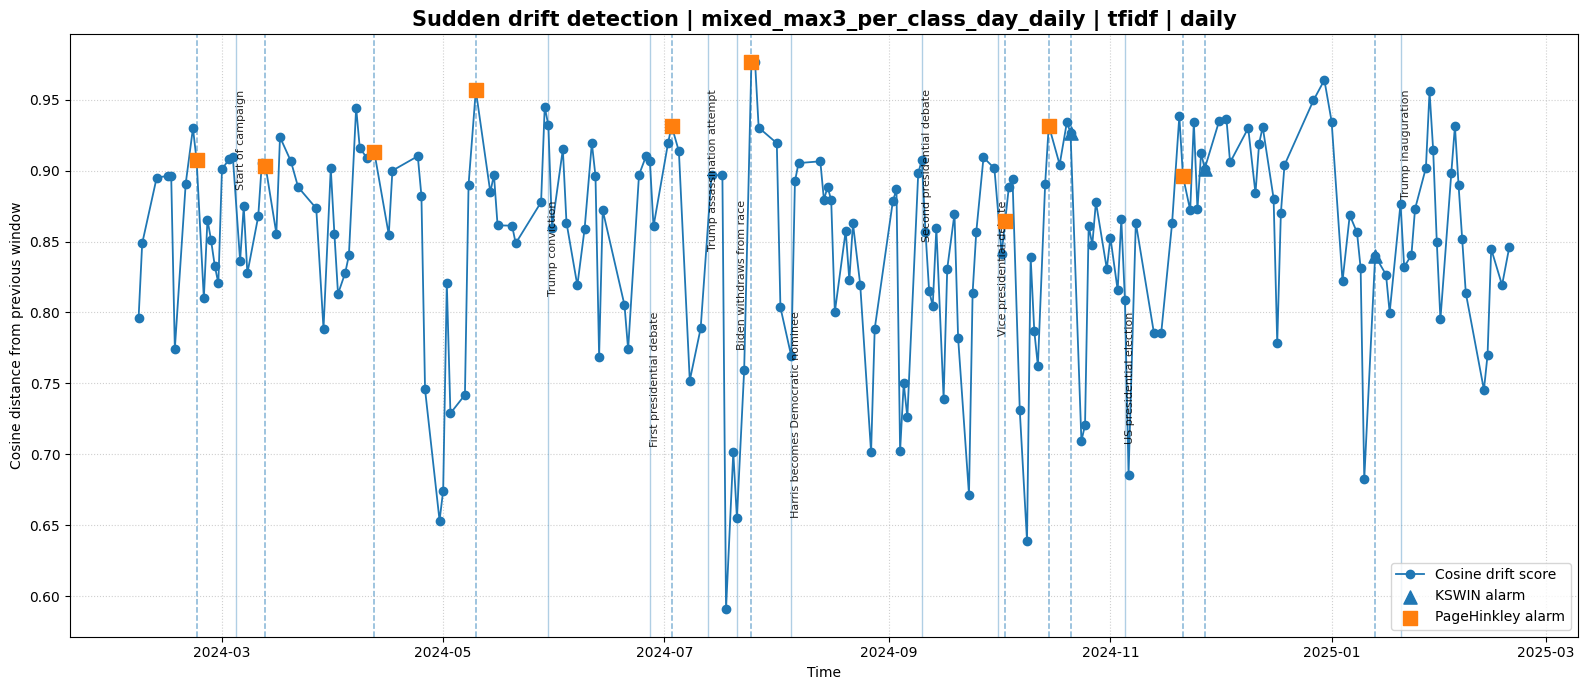

Saved plot: results\sudden_drift_detection\tfidf\daily\mixed_raw_daily\plot.png


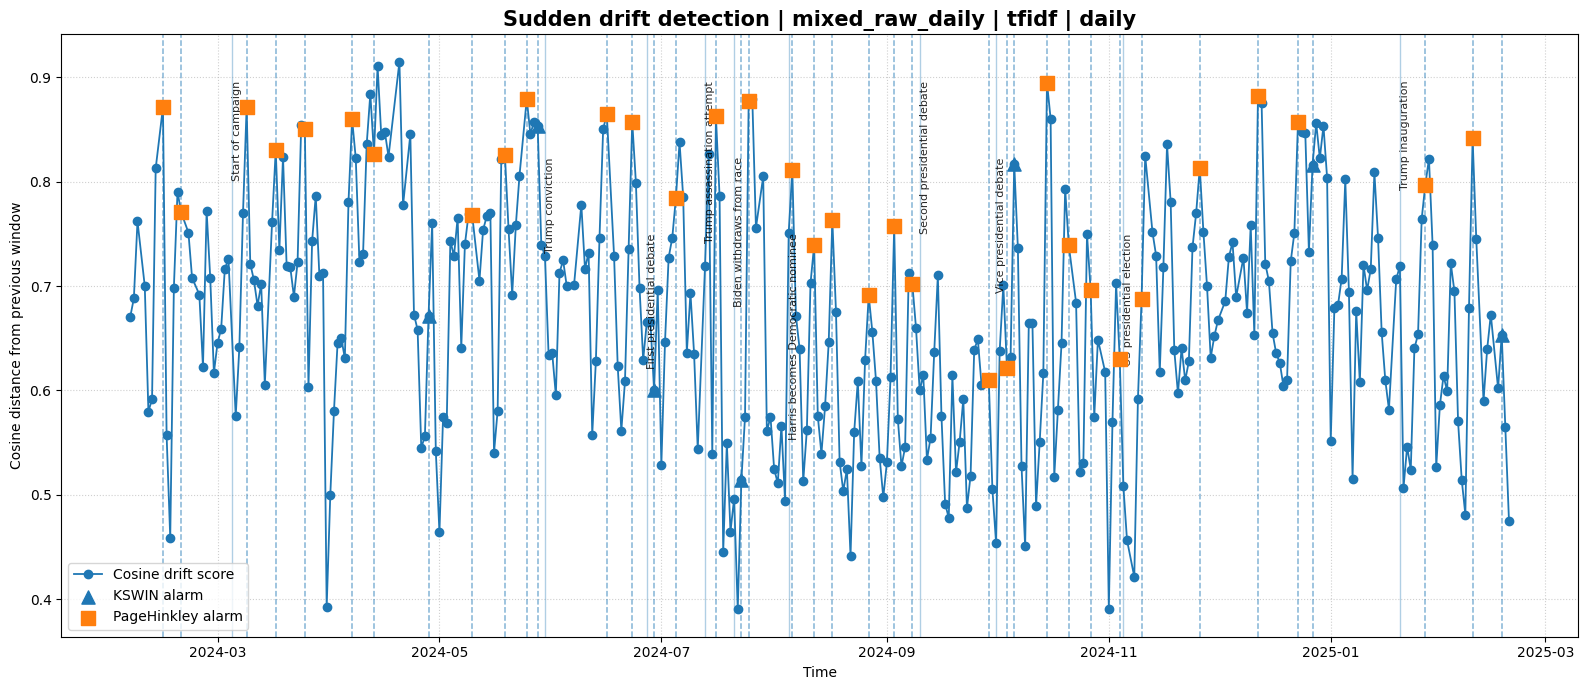

Saved plot: results\sudden_drift_detection\tfidf\daily\mixed_split_minority_day_daily\plot.png


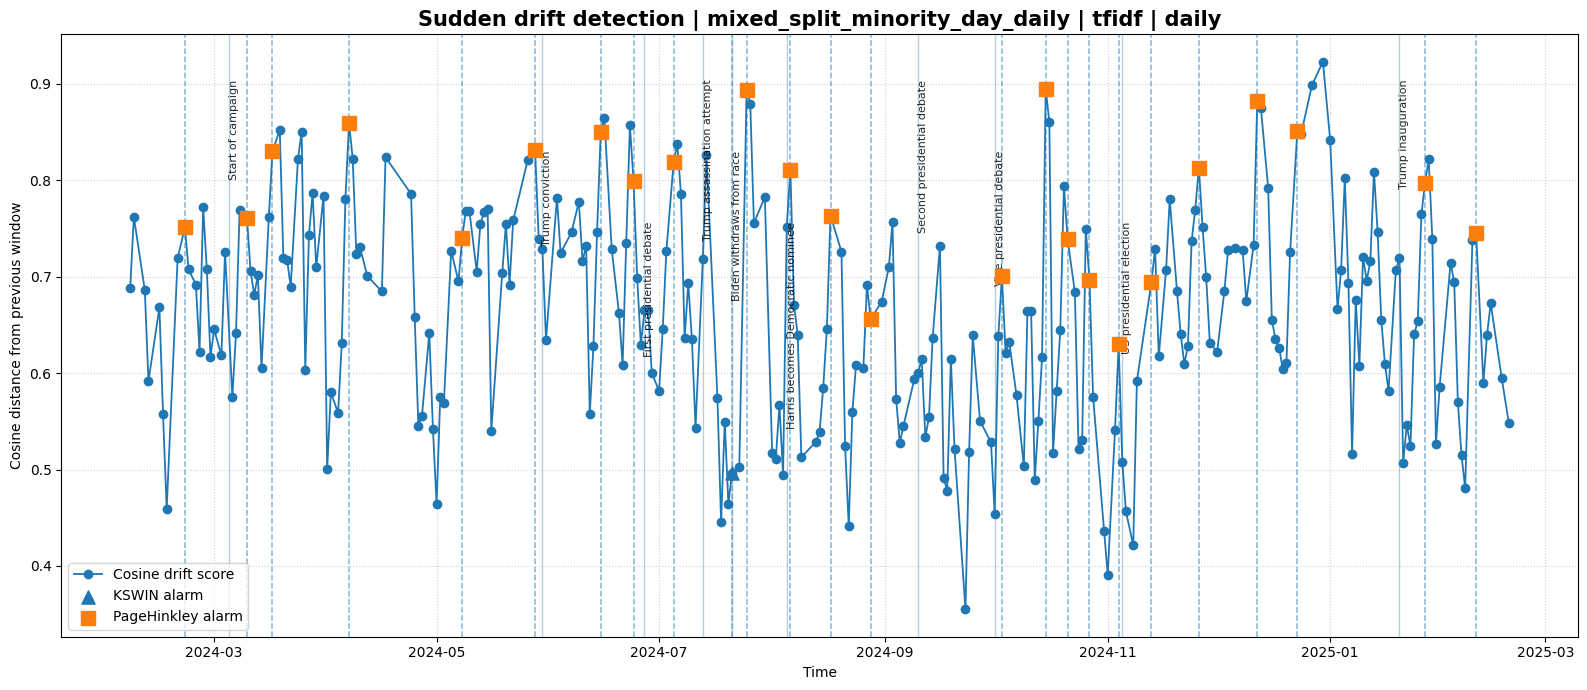

Saved plot: results\sudden_drift_detection\tfidf\daily\right_none_daily\plot.png


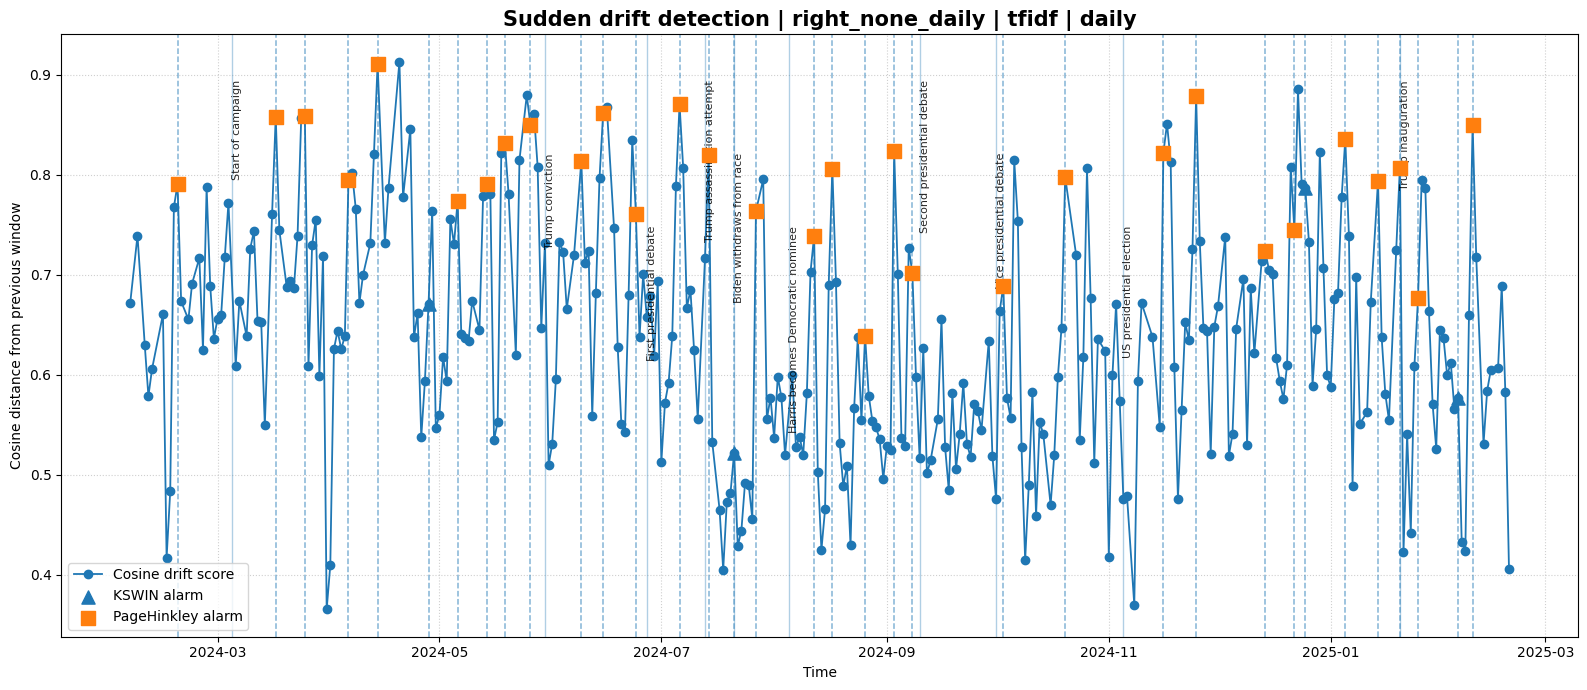

Running case: feature=embedding | window=daily
Number of aggregated windows: 1,421
Windows per stream:


,stream_group,stream_family,sampling,windows,total_articles,avg_articles
0,left_none_daily,left,none,70,418,5.971429
1,mixed_global_undersampled_daily,mixed,global_undersampled,180,1352,7.511111
2,mixed_max3_per_class_day_daily,mixed,max3_per_class_day,201,1151,5.726368
3,mixed_raw_daily,mixed,raw,355,6476,18.242254
4,mixed_split_minority_day_daily,mixed,split_minority_day,277,8920,32.202166
5,right_none_daily,right,none,338,5556,16.437870


Building embedding features...


c:\Users\krzys\OneDrive\Pulpit\Studia\StudiaDS\2sem\MLDSt\Project\Concept-Drift-Detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 356/356 [28:17<00:00,  4.77s/it] 


Feature matrix shape: (1421, 384)
Computing cosine drift scores...
Number of drift-score observations: 1,415
Running River detectors...
[DRIFT] left_none_daily | PageHinkley | 2024-04-01 | score=0.8258
[DRIFT] left_none_daily | PageHinkley | 2024-04-24 | score=0.8446
[DRIFT] left_none_daily | PageHinkley | 2024-07-17 | score=0.8492
[DRIFT] left_none_daily | PageHinkley | 2024-08-07 | score=1.0112
[DRIFT] left_none_daily | PageHinkley | 2024-09-20 | score=0.8672
[DRIFT] left_none_daily | KSWIN | 2024-10-25 | score=0.6566
[DRIFT] left_none_daily | PageHinkley | 2024-12-03 | score=0.8279
[DRIFT] left_none_daily | PageHinkley | 2025-01-23 | score=0.9266
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-02-22 | score=0.7537
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-02-29 | score=1.0483
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-03-27 | score=0.6979
[DRIFT] mixed_global_undersampled_daily | PageHinkley | 2024-04-17 | score=0.9182
[DRIFT] mixed_

,feature_type,stream_group,stream_source,stream_family,sampling,detector,time_window_code,time_window_name,detections,true_positives,false_positives,precision_like,avg_delay_days,events_detected,events_missed,event_recall
7,embedding,mixed_max3_per_class_day_daily,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,D,daily,25,11,14,0.440000,-1.636364,9,1,0.9
10,embedding,mixed_raw_daily,mixed_raw,mixed,raw,PageHinkley,D,daily,36,12,24,0.333333,-0.500000,9,1,0.9
16,embedding,right_none_daily,right_none,right,none,PageHinkley,D,daily,33,12,21,0.363636,-1.166667,8,2,0.8
13,embedding,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,D,daily,31,11,20,0.354839,0.272727,8,2,0.8
4,embedding,mixed_global_undersampled_daily,mixed_global_undersampled,mixed,global_undersampled,PageHinkley,D,daily,18,7,11,0.388889,-1.000000,7,3,0.7
1,embedding,left_none_daily,left_none,left,none,PageHinkley,D,daily,7,3,4,0.428571,3.000000,3,7,0.3
8,embedding,mixed_max3_per_class_day_daily,mixed_max3_per_class_day,mixed,max3_per_class_day,KSWIN,D,daily,3,2,1,0.666667,-0.500000,2,8,0.2
5,embedding,mixed_global_undersampled_daily,mixed_global_undersampled,mixed,global_undersampled,KSWIN,D,daily,4,1,3,0.250000,6.000000,1,9,0.1
11,embedding,mixed_raw_daily,mixed_raw,mixed,raw,KSWIN,D,daily,4,1,3,0.250000,-2.000000,1,9,0.1
2,embedding,left_none_daily,left_none,left,none,KSWIN,D,daily,1,0,1,0.000000,NaN,0,10,0.0


Saving case results...
Saved case results: results\sudden_drift_detection\embedding\daily\_global
Creating plots...
Saved plot: results\sudden_drift_detection\embedding\daily\left_none_daily\plot.png


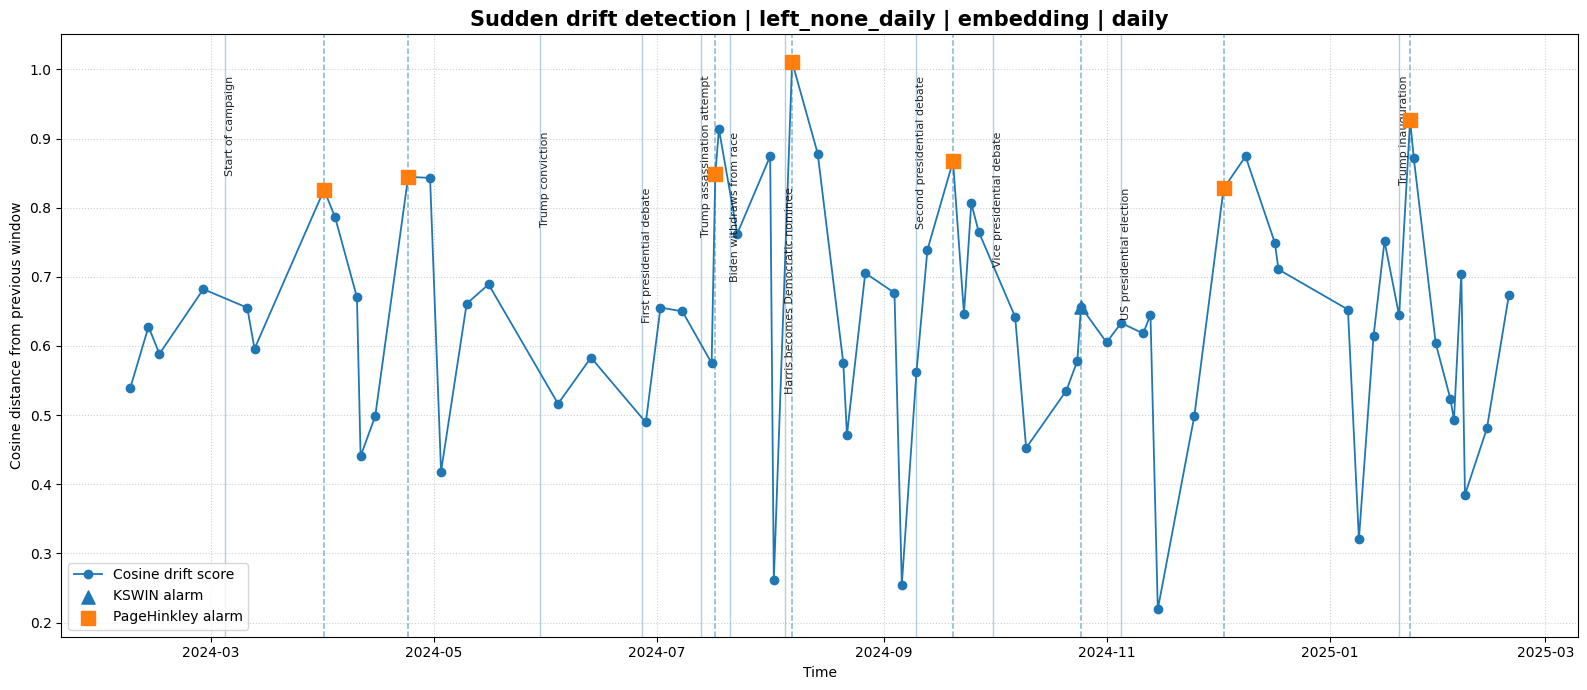

Saved plot: results\sudden_drift_detection\embedding\daily\mixed_global_undersampled_daily\plot.png


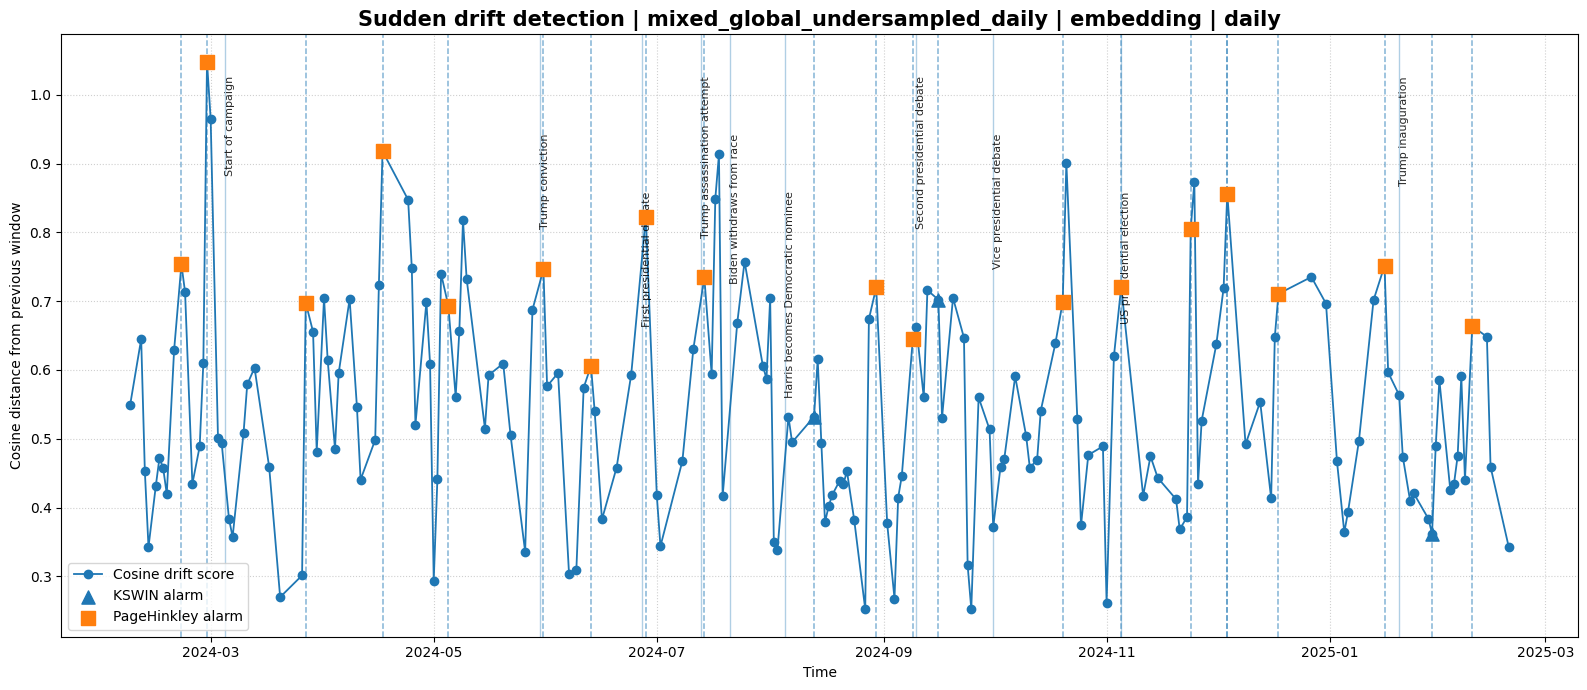

Saved plot: results\sudden_drift_detection\embedding\daily\mixed_max3_per_class_day_daily\plot.png


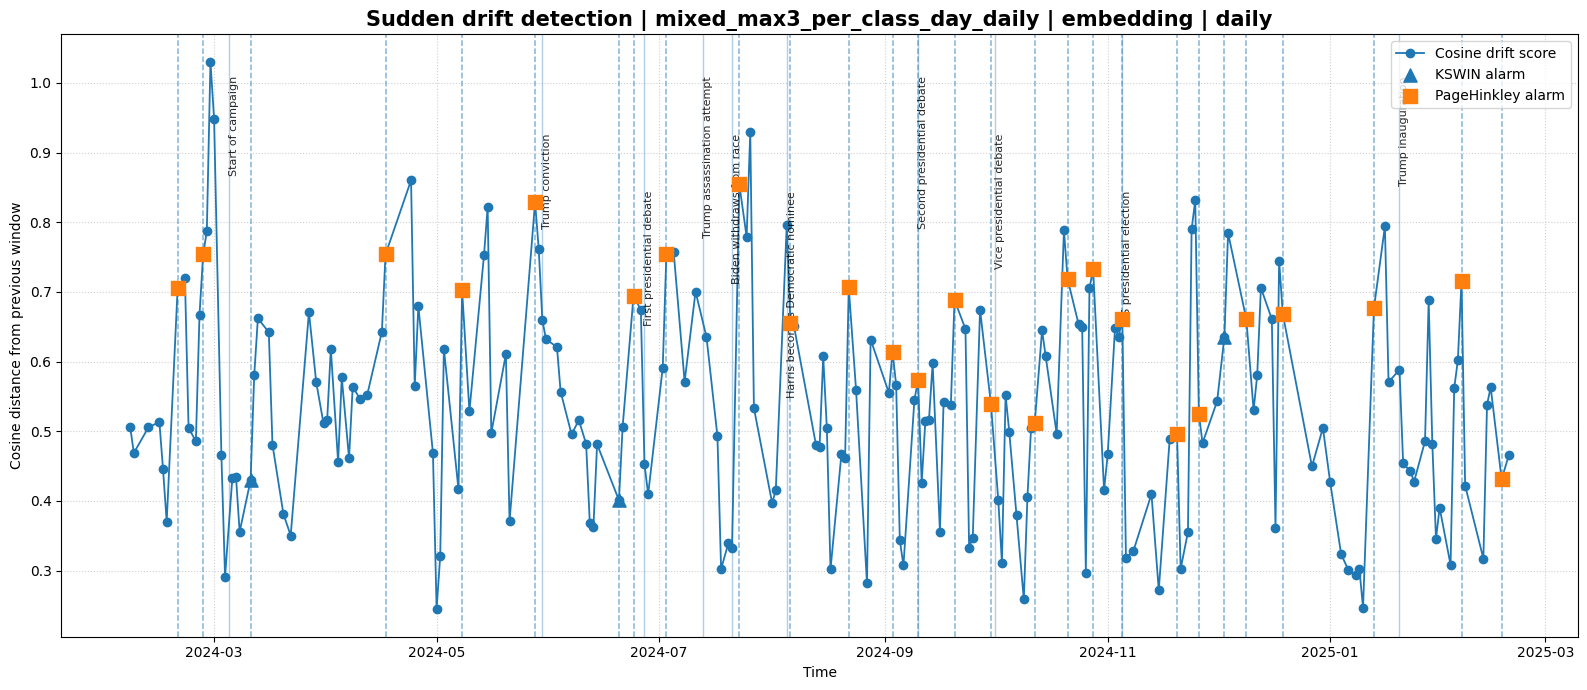

Saved plot: results\sudden_drift_detection\embedding\daily\mixed_raw_daily\plot.png


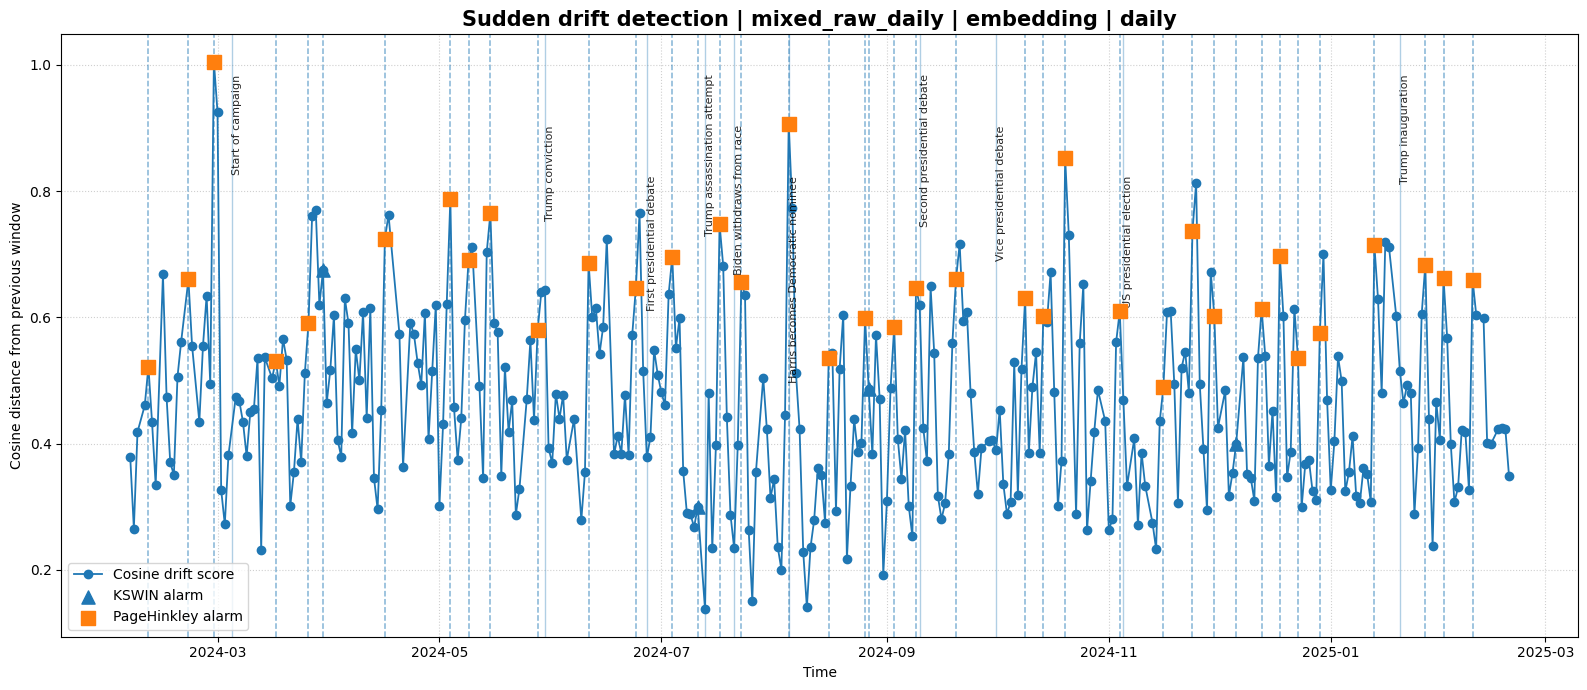

Saved plot: results\sudden_drift_detection\embedding\daily\mixed_split_minority_day_daily\plot.png


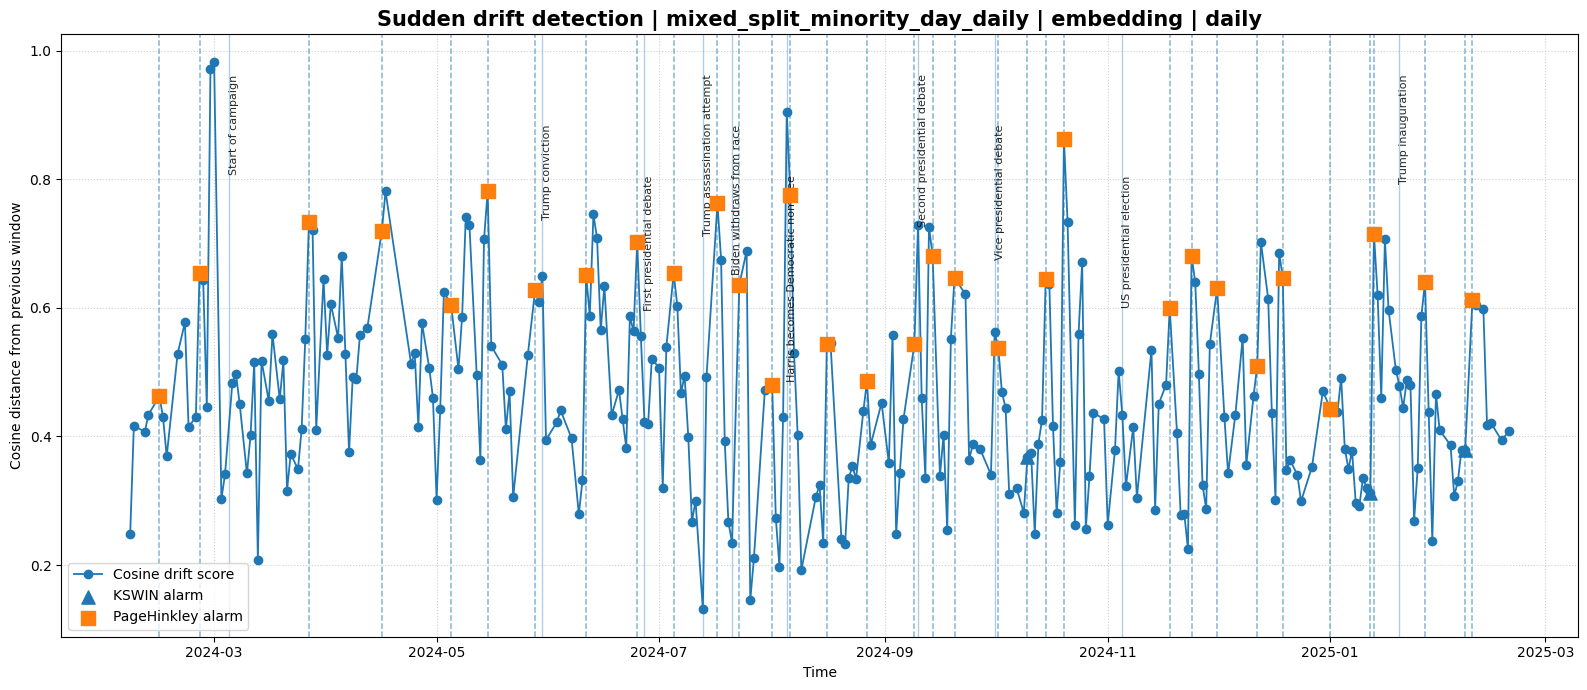

Saved plot: results\sudden_drift_detection\embedding\daily\right_none_daily\plot.png


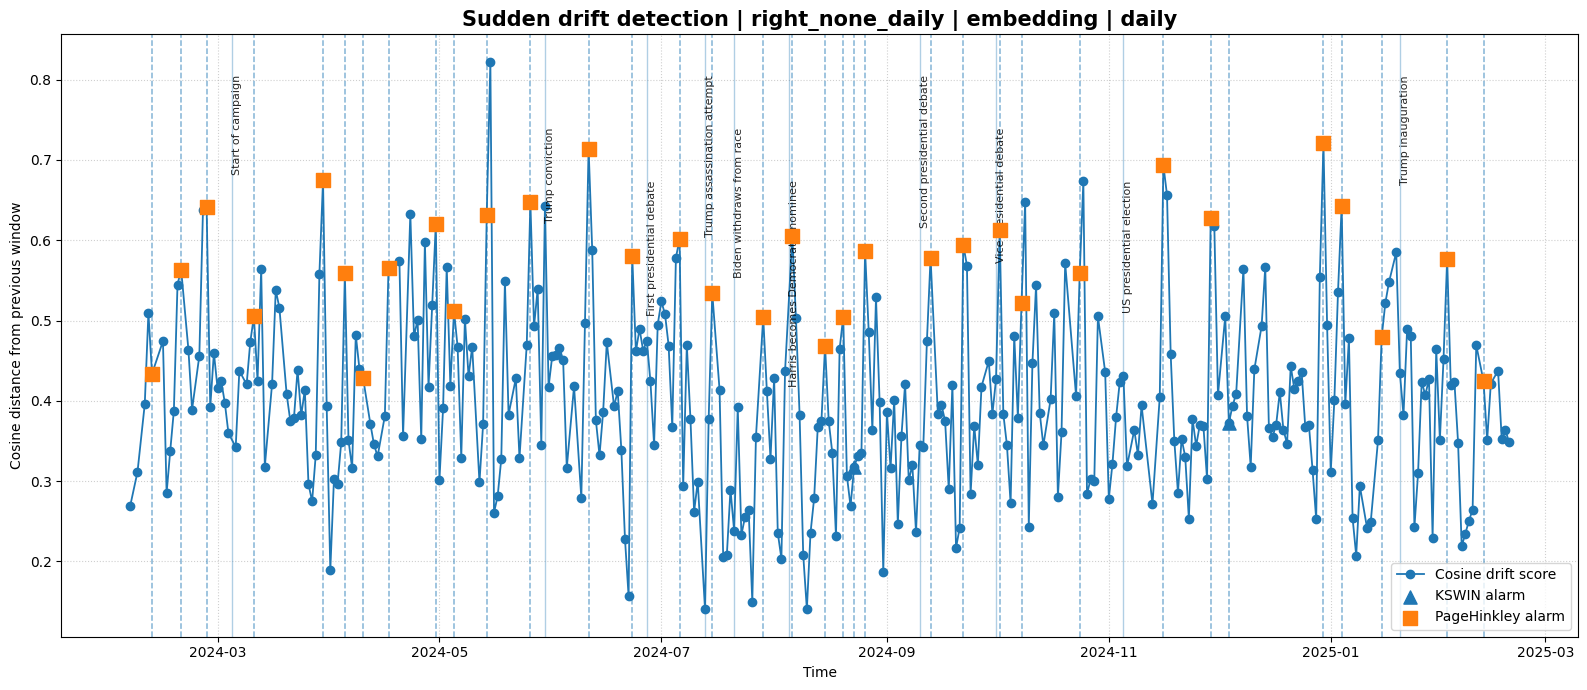

Running case: feature=tfidf | window=weekly
Number of aggregated windows: 313
Windows per stream:


,stream_group,stream_family,sampling,windows,total_articles,avg_articles
0,left_none_weekly,left,none,39,746,19.128205
1,mixed_global_undersampled_weekly,mixed,global_undersampled,55,1846,33.563636
2,mixed_max3_per_class_day_weekly,mixed,max3_per_class_day,54,1734,32.111111
3,mixed_raw_weekly,mixed,raw,55,6543,118.963636
4,mixed_split_minority_day_weekly,mixed,split_minority_day,55,8926,162.290909
5,right_none_weekly,right,none,55,5620,102.181818


Building tfidf features...
Feature matrix shape: (313, 10000)
Computing cosine drift scores...
Number of drift-score observations: 307
Running River detectors...
[DRIFT] left_none_weekly | PageHinkley | 2024-11-25 | score=0.9099
[DRIFT] left_none_weekly | PageHinkley | 2025-01-27 | score=0.8694
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-03-25 | score=0.7640
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-07-22 | score=0.8900
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-10-21 | score=0.7357
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-11-18 | score=0.7395
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-12-30 | score=0.9245
[DRIFT] mixed_max3_per_class_day_weekly | PageHinkley | 2024-04-01 | score=0.8010
[DRIFT] mixed_max3_per_class_day_weekly | PageHinkley | 2024-07-22 | score=0.8867
[DRIFT] mixed_max3_per_class_day_weekly | PageHinkley | 2024-11-25 | score=0.7971
[DRIFT] mixed_max3_per_class_day_weekly | P

,feature_type,stream_group,stream_source,stream_family,sampling,detector,time_window_code,time_window_name,detections,true_positives,false_positives,precision_like,avg_delay_days,events_detected,events_missed,event_recall
13,tfidf,mixed_split_minority_day_weekly,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,W,weekly,6,3,3,0.50,-2.666667,3,7,0.3
4,tfidf,mixed_global_undersampled_weekly,mixed_global_undersampled,mixed,global_undersampled,PageHinkley,W,weekly,5,2,3,0.40,7.000000,2,8,0.2
1,tfidf,left_none_weekly,left_none,left,none,PageHinkley,W,weekly,2,1,1,0.50,7.000000,1,9,0.1
16,tfidf,right_none_weekly,right_none,right,none,PageHinkley,W,weekly,2,1,1,0.50,-7.000000,1,9,0.1
7,tfidf,mixed_max3_per_class_day_weekly,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,W,weekly,4,1,3,0.25,1.000000,1,9,0.1
10,tfidf,mixed_raw_weekly,mixed_raw,mixed,raw,PageHinkley,W,weekly,4,1,3,0.25,1.000000,1,9,0.1
0,tfidf,left_none_weekly,left_none,left,none,ADWIN,W,weekly,0,0,0,NaN,NaN,0,10,0.0
2,tfidf,left_none_weekly,left_none,left,none,KSWIN,W,weekly,0,0,0,NaN,NaN,0,10,0.0
3,tfidf,mixed_global_undersampled_weekly,mixed_global_undersampled,mixed,global_undersampled,ADWIN,W,weekly,0,0,0,NaN,NaN,0,10,0.0
5,tfidf,mixed_global_undersampled_weekly,mixed_global_undersampled,mixed,global_undersampled,KSWIN,W,weekly,0,0,0,NaN,NaN,0,10,0.0


Saving case results...
Saved case results: results\sudden_drift_detection\tfidf\weekly\_global
Creating plots...
Saved plot: results\sudden_drift_detection\tfidf\weekly\left_none_weekly\plot.png


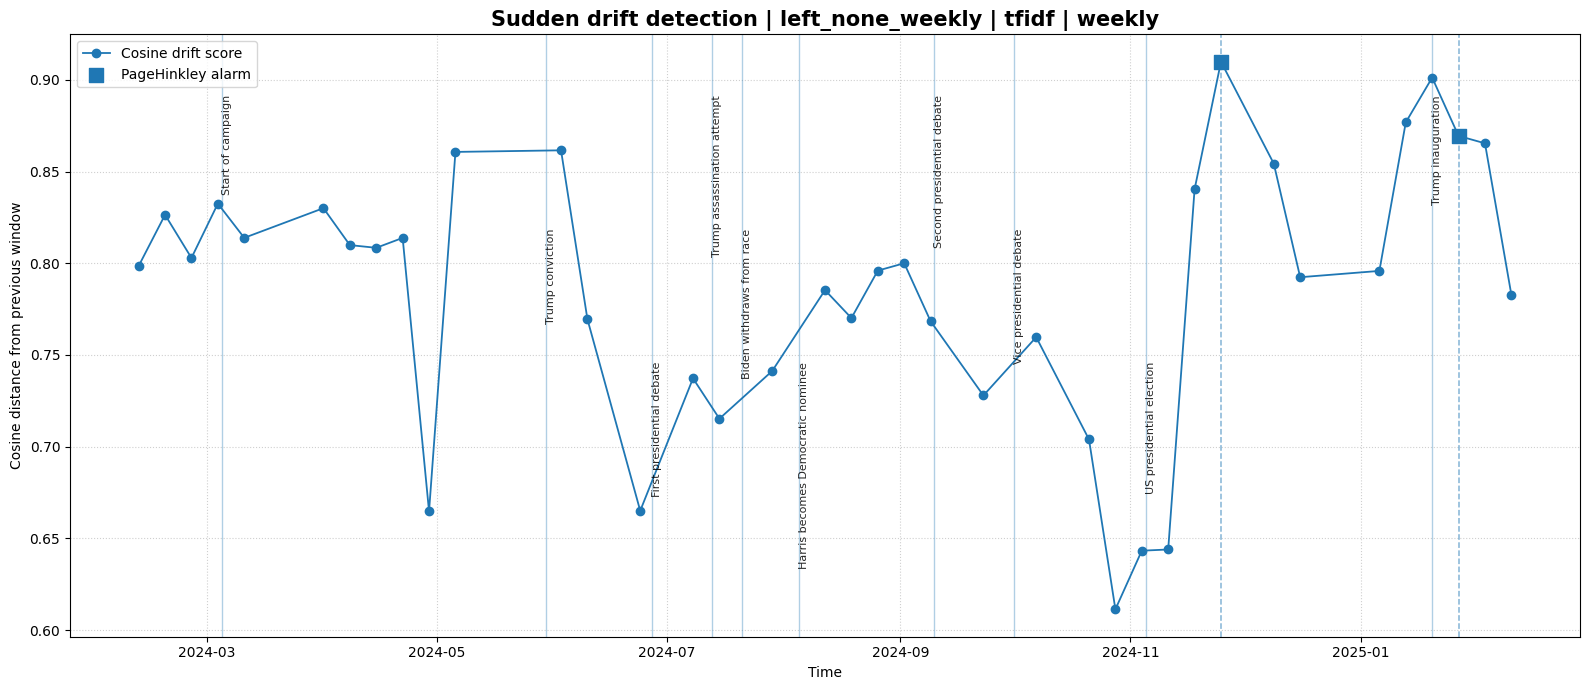

Saved plot: results\sudden_drift_detection\tfidf\weekly\mixed_global_undersampled_weekly\plot.png


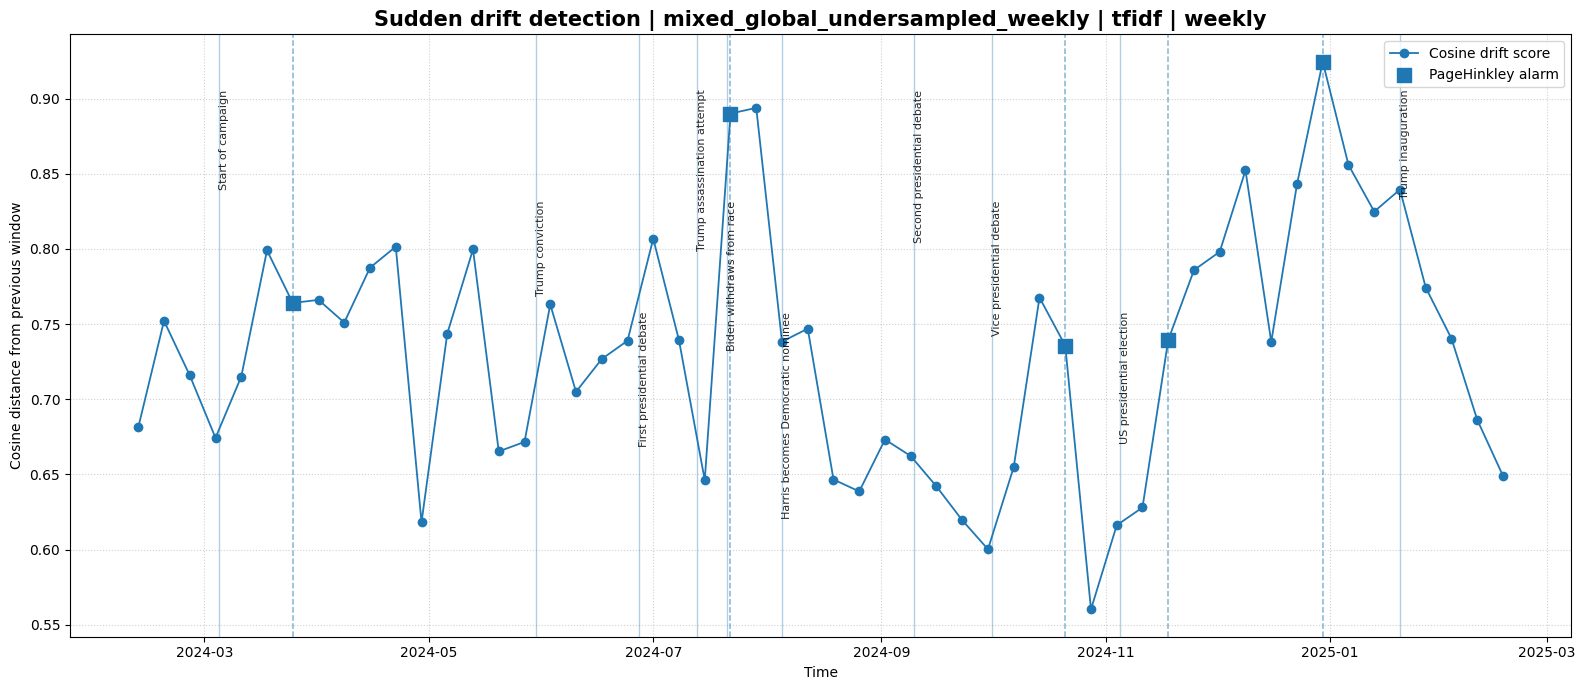

Saved plot: results\sudden_drift_detection\tfidf\weekly\mixed_max3_per_class_day_weekly\plot.png


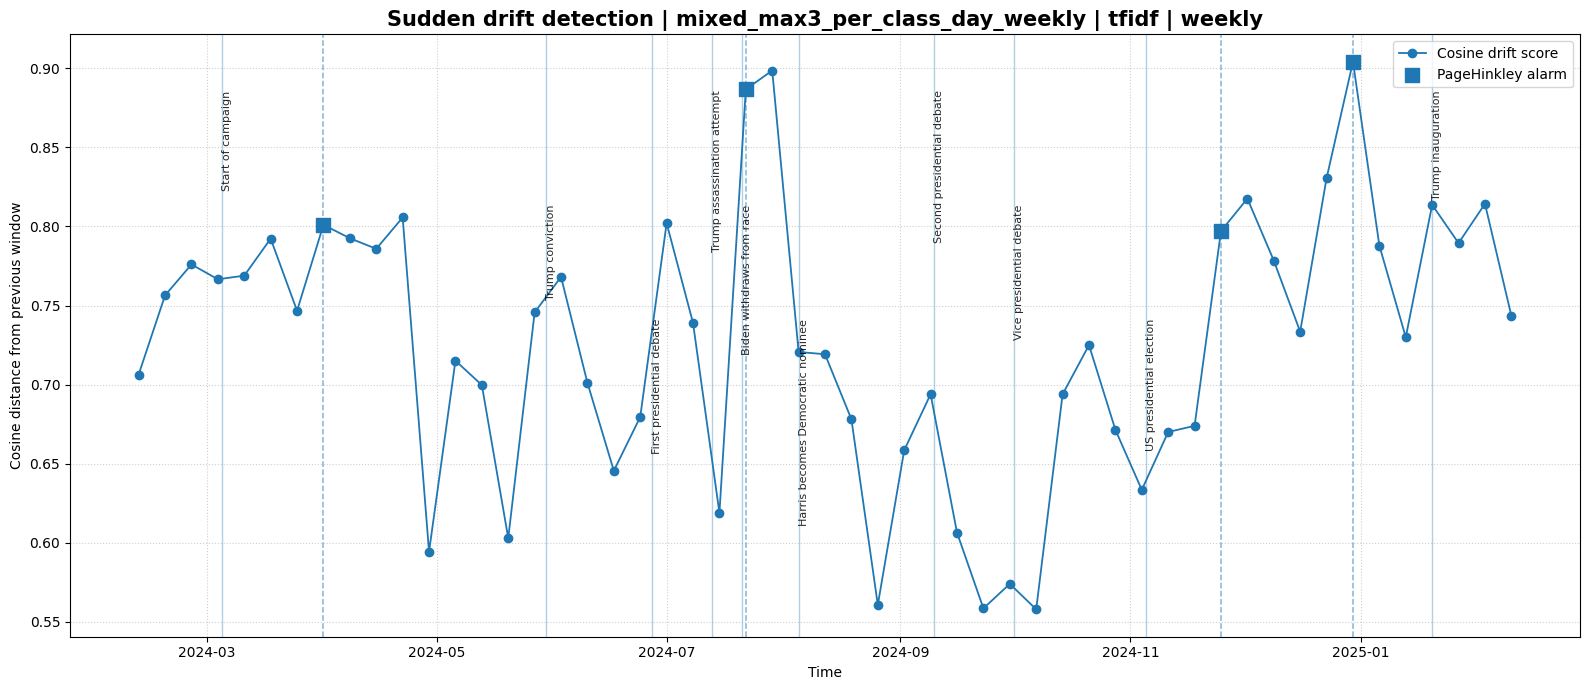

Saved plot: results\sudden_drift_detection\tfidf\weekly\mixed_raw_weekly\plot.png


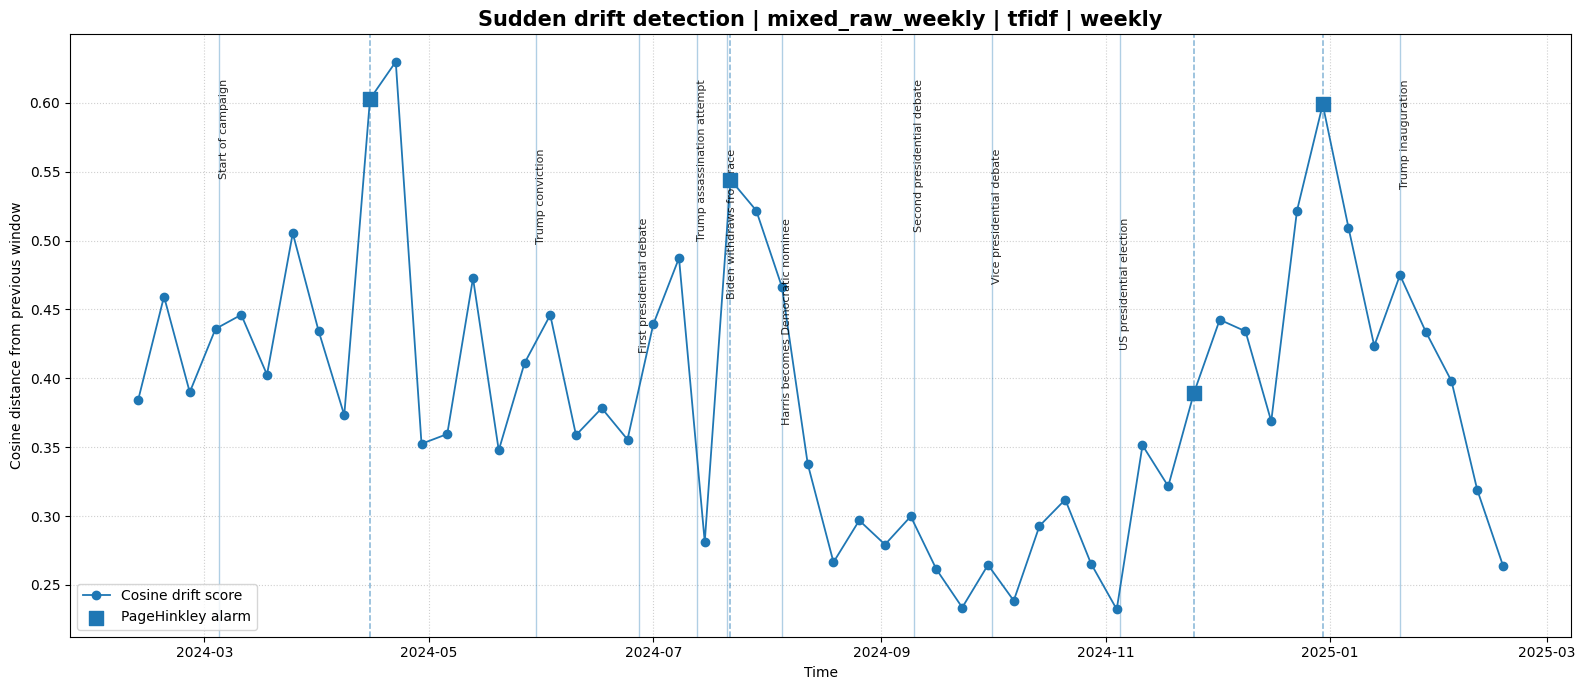

Saved plot: results\sudden_drift_detection\tfidf\weekly\mixed_split_minority_day_weekly\plot.png


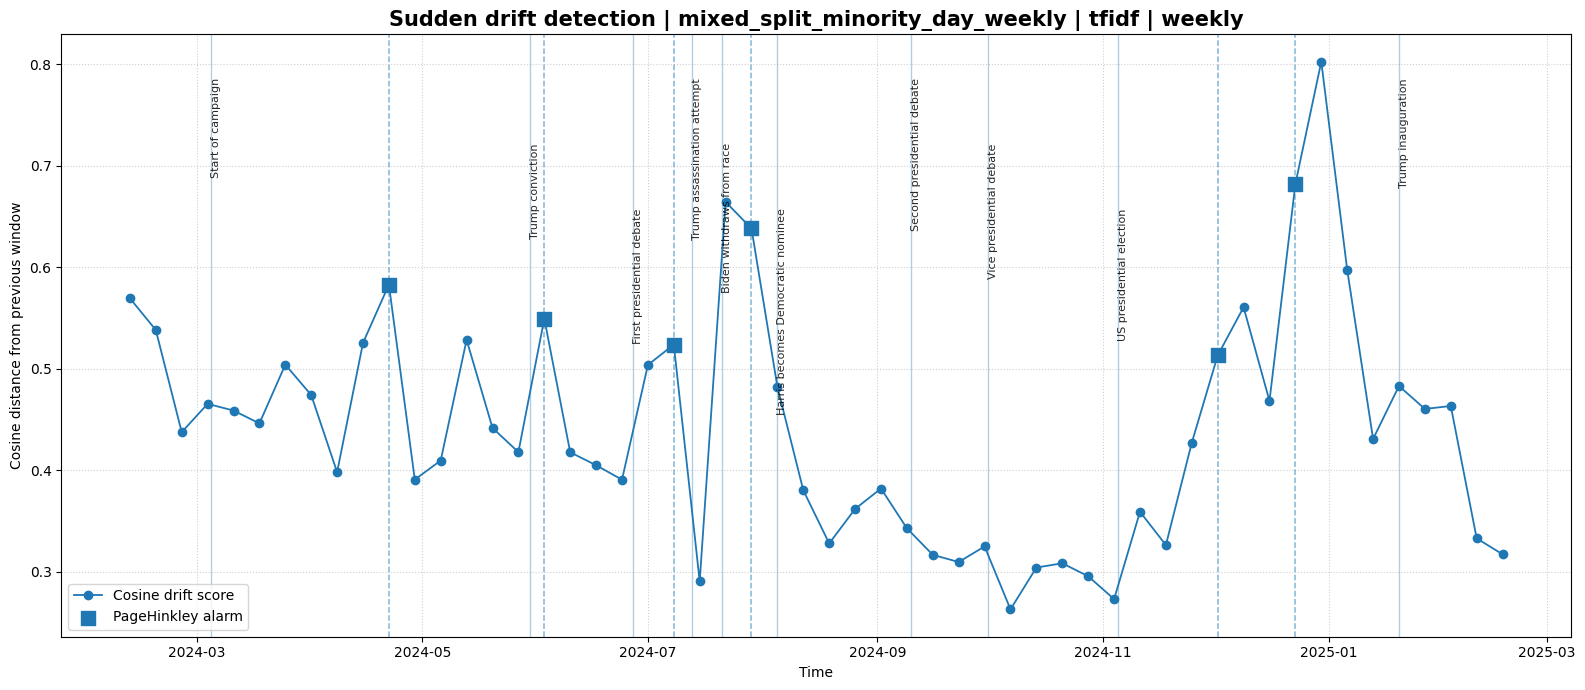

Saved plot: results\sudden_drift_detection\tfidf\weekly\right_none_weekly\plot.png


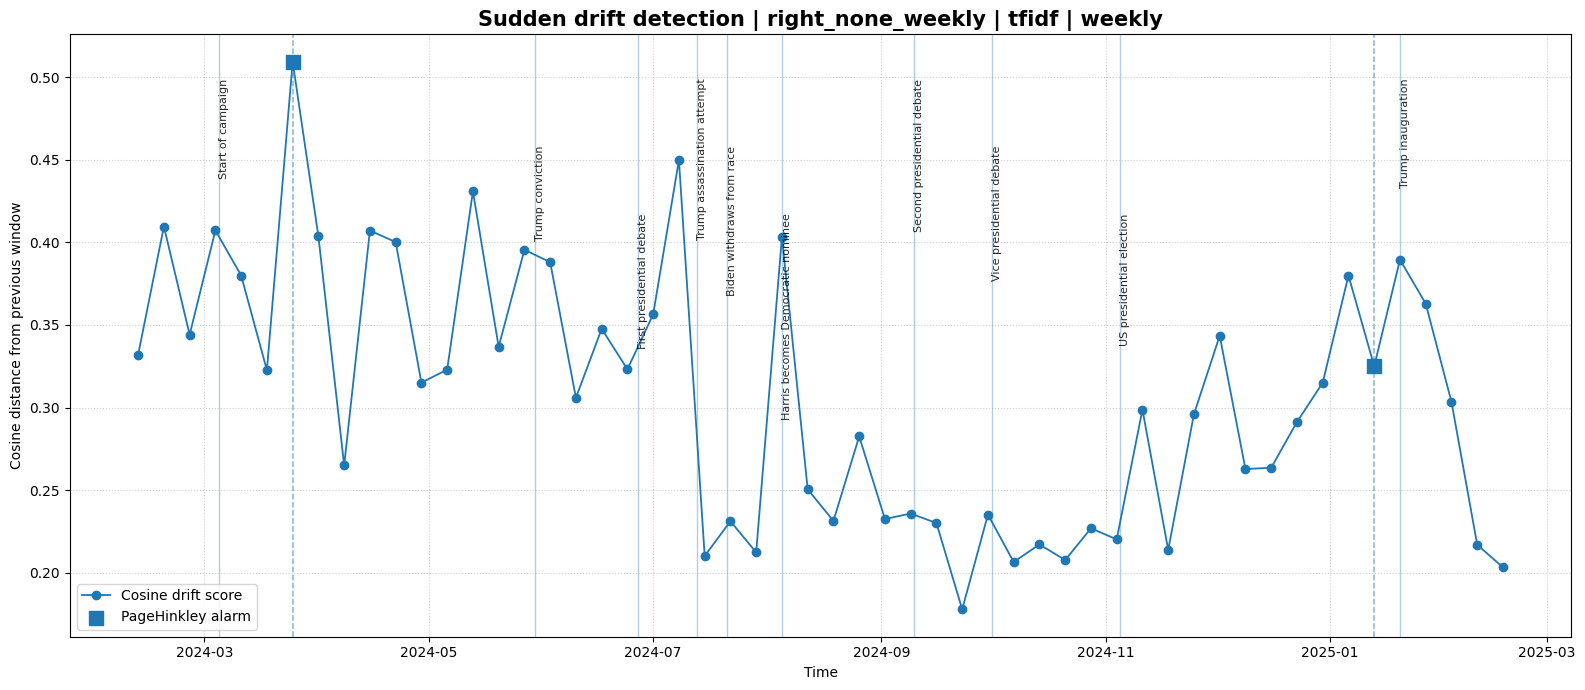

Running case: feature=embedding | window=weekly
Number of aggregated windows: 313
Windows per stream:


,stream_group,stream_family,sampling,windows,total_articles,avg_articles
0,left_none_weekly,left,none,39,746,19.128205
1,mixed_global_undersampled_weekly,mixed,global_undersampled,55,1846,33.563636
2,mixed_max3_per_class_day_weekly,mixed,max3_per_class_day,54,1734,32.111111
3,mixed_raw_weekly,mixed,raw,55,6543,118.963636
4,mixed_split_minority_day_weekly,mixed,split_minority_day,55,8926,162.290909
5,right_none_weekly,right,none,55,5620,102.181818


Building embedding features...


Batches: 100%|██████████| 79/79 [02:39<00:00,  2.01s/it]


Feature matrix shape: (313, 384)
Computing cosine drift scores...
Number of drift-score observations: 307
Running River detectors...
[DRIFT] left_none_weekly | PageHinkley | 2024-02-26 | score=0.7003
[DRIFT] left_none_weekly | PageHinkley | 2024-04-08 | score=0.7003
[DRIFT] left_none_weekly | PageHinkley | 2024-04-29 | score=0.7620
[DRIFT] left_none_weekly | PageHinkley | 2024-06-24 | score=0.9065
[DRIFT] left_none_weekly | PageHinkley | 2024-11-04 | score=0.8483
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-02-26 | score=0.7003
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-04-01 | score=0.7588
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-06-17 | score=0.8751
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-08-05 | score=0.7624
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-10-14 | score=0.7098
[DRIFT] mixed_global_undersampled_weekly | PageHinkley | 2024-12-02 | score=0.8155
[DRIFT] mixed_global_undersampled_

,feature_type,stream_group,stream_source,stream_family,sampling,detector,time_window_code,time_window_name,detections,true_positives,false_positives,precision_like,avg_delay_days,events_detected,events_missed,event_recall
7,embedding,mixed_max3_per_class_day_weekly,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,W,weekly,9,8,1,0.888889,1.375000,8,2,0.8
13,embedding,mixed_split_minority_day_weekly,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,W,weekly,9,6,3,0.666667,-2.833333,6,4,0.6
4,embedding,mixed_global_undersampled_weekly,mixed_global_undersampled,mixed,global_undersampled,PageHinkley,W,weekly,7,5,2,0.714286,-1.000000,5,5,0.5
16,embedding,right_none_weekly,right_none,right,none,PageHinkley,W,weekly,7,5,2,0.714286,1.600000,4,6,0.4
10,embedding,mixed_raw_weekly,mixed_raw,mixed,raw,PageHinkley,W,weekly,6,4,2,0.666667,-2.750000,4,6,0.4
1,embedding,left_none_weekly,left_none,left,none,PageHinkley,W,weekly,5,3,2,0.600000,-4.000000,3,7,0.3
0,embedding,left_none_weekly,left_none,left,none,ADWIN,W,weekly,0,0,0,NaN,NaN,0,10,0.0
2,embedding,left_none_weekly,left_none,left,none,KSWIN,W,weekly,0,0,0,NaN,NaN,0,10,0.0
3,embedding,mixed_global_undersampled_weekly,mixed_global_undersampled,mixed,global_undersampled,ADWIN,W,weekly,0,0,0,NaN,NaN,0,10,0.0
5,embedding,mixed_global_undersampled_weekly,mixed_global_undersampled,mixed,global_undersampled,KSWIN,W,weekly,0,0,0,NaN,NaN,0,10,0.0


Saving case results...
Saved case results: results\sudden_drift_detection\embedding\weekly\_global
Creating plots...
Saved plot: results\sudden_drift_detection\embedding\weekly\left_none_weekly\plot.png


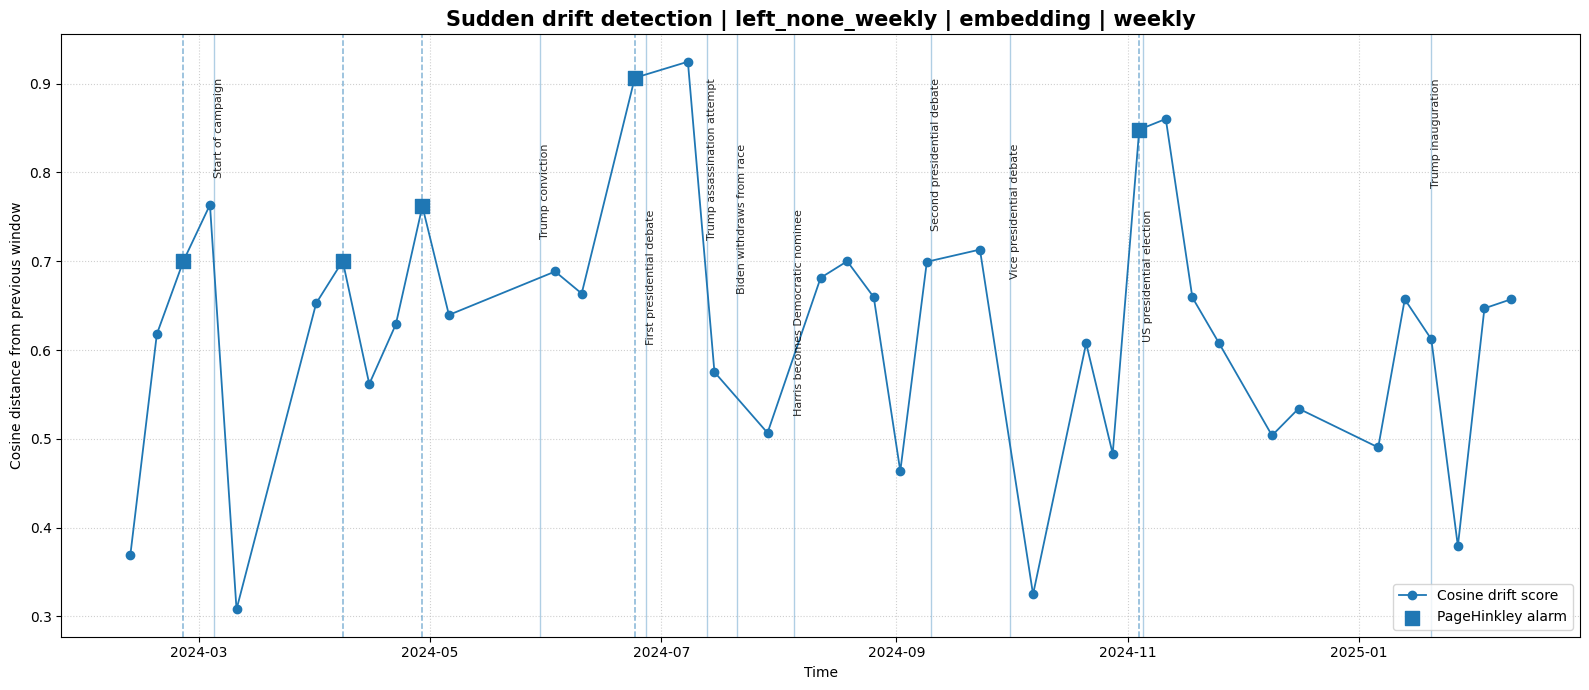

Saved plot: results\sudden_drift_detection\embedding\weekly\mixed_global_undersampled_weekly\plot.png


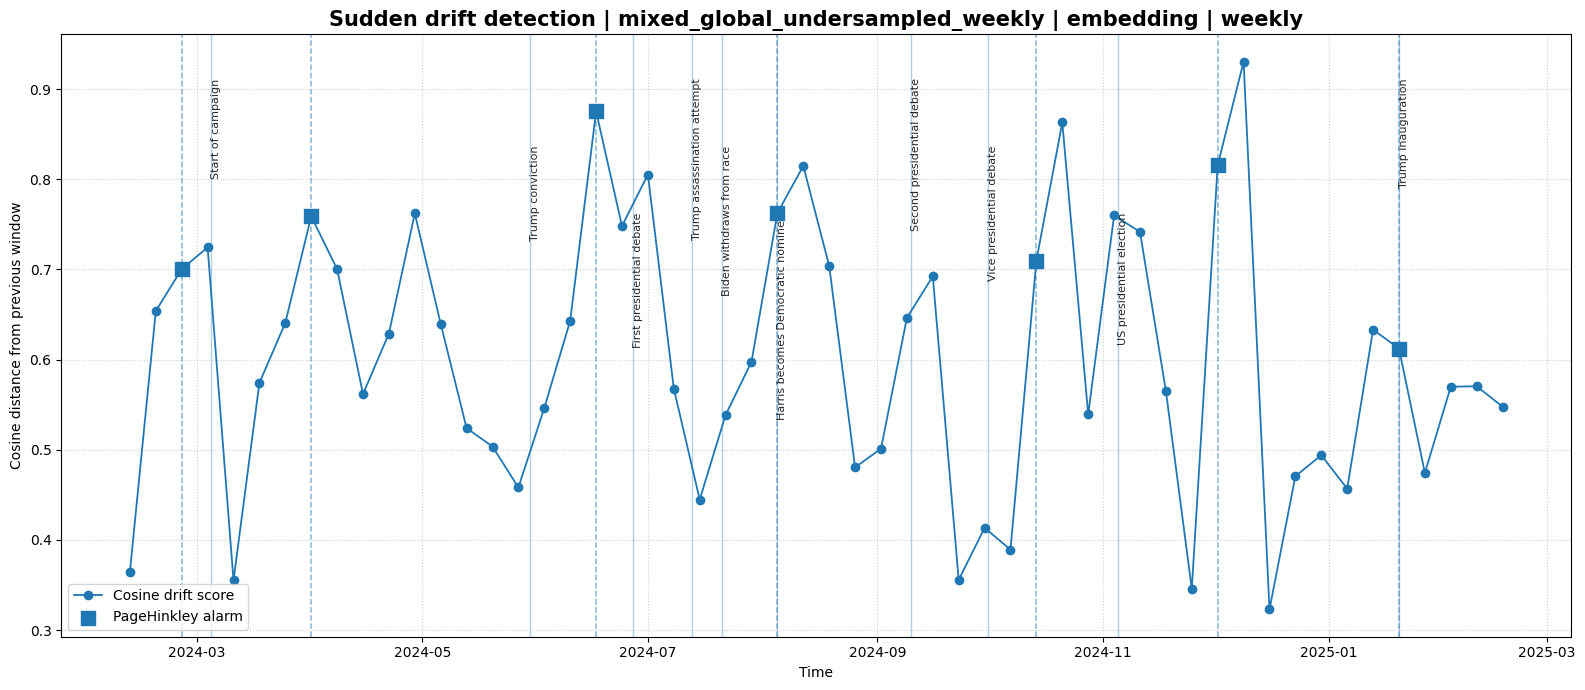

Saved plot: results\sudden_drift_detection\embedding\weekly\mixed_max3_per_class_day_weekly\plot.png


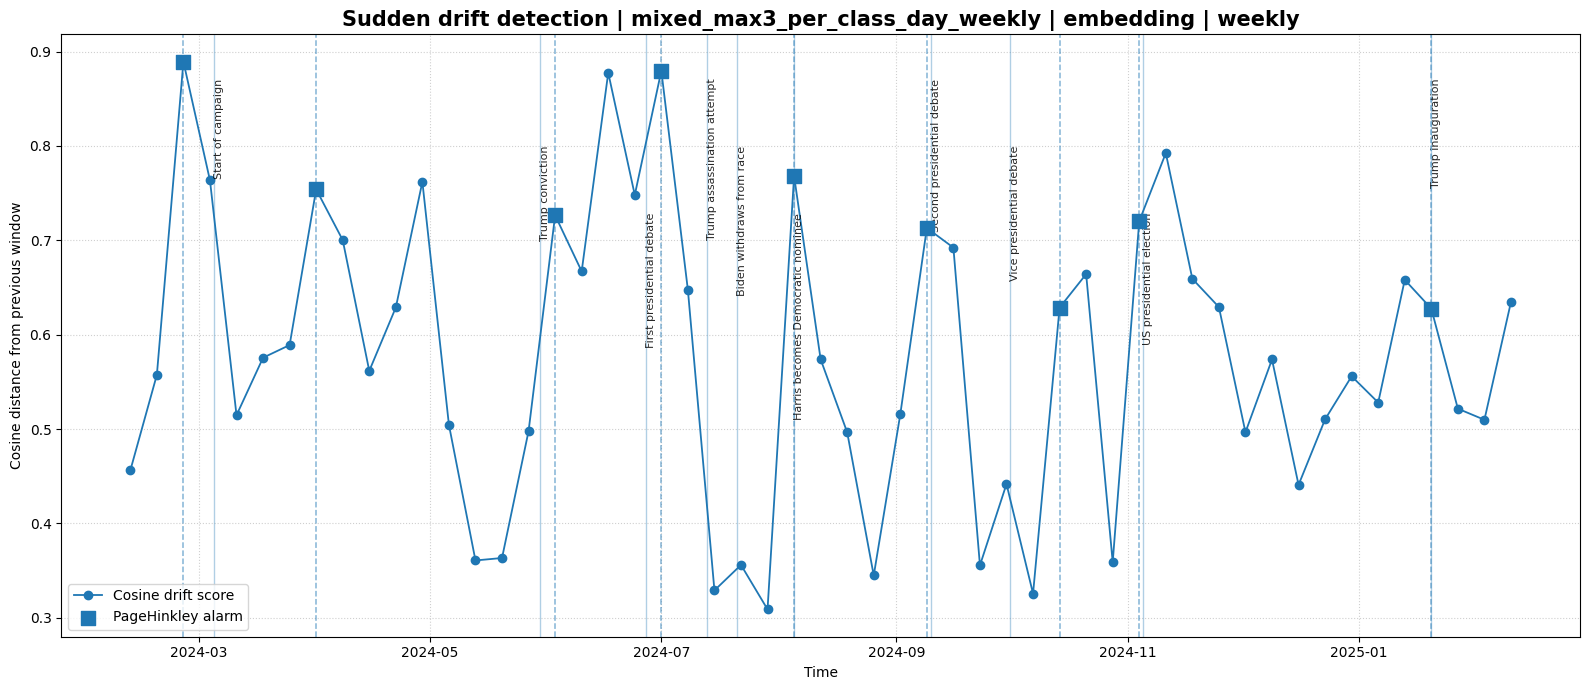

Saved plot: results\sudden_drift_detection\embedding\weekly\mixed_raw_weekly\plot.png


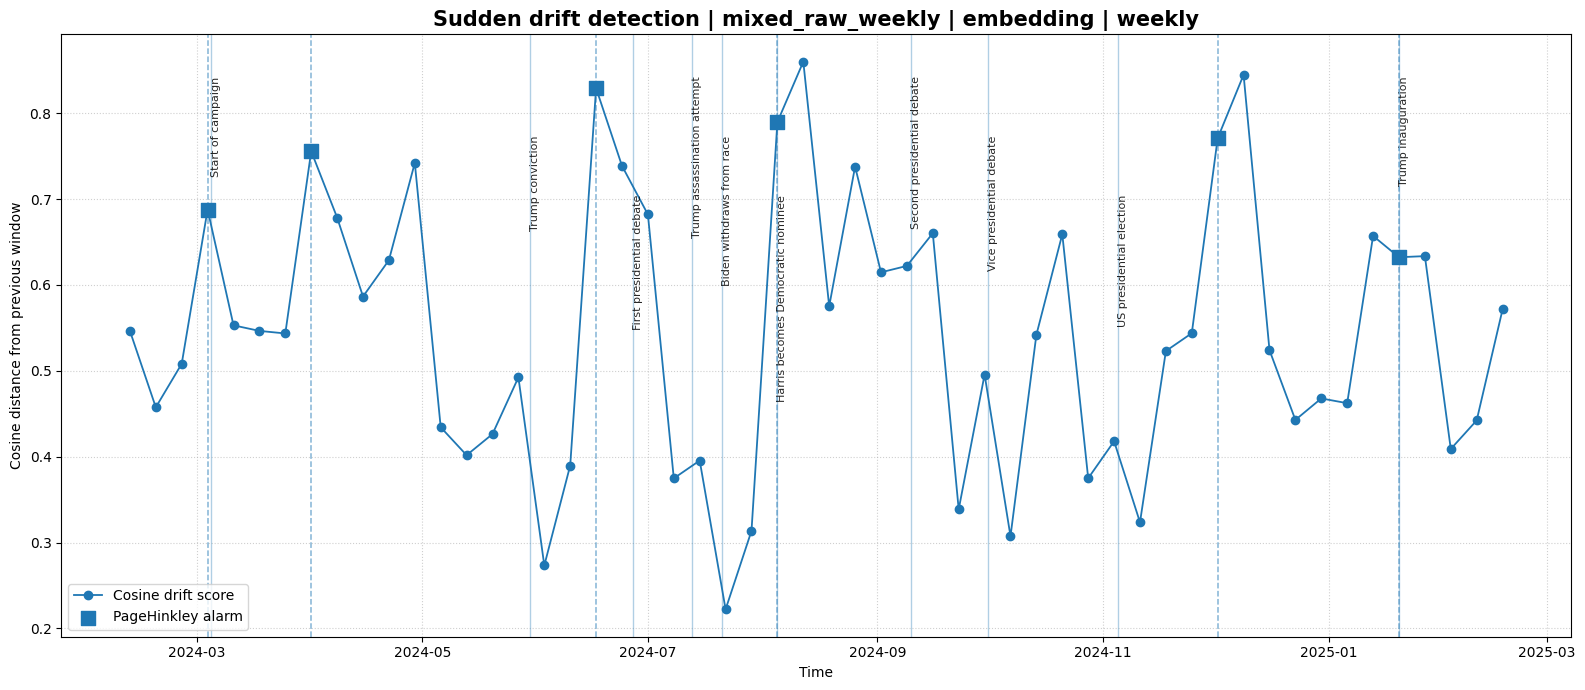

Saved plot: results\sudden_drift_detection\embedding\weekly\mixed_split_minority_day_weekly\plot.png


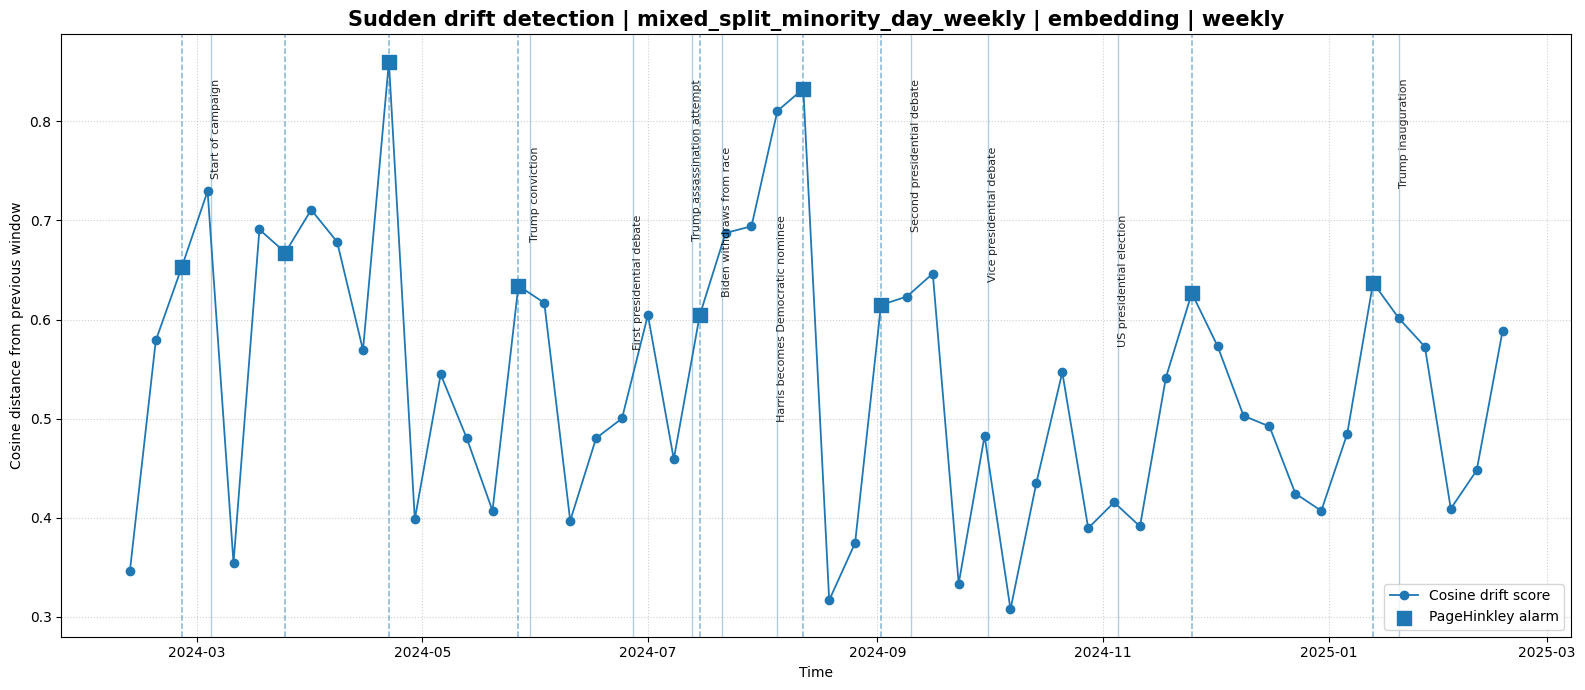

Saved plot: results\sudden_drift_detection\embedding\weekly\right_none_weekly\plot.png


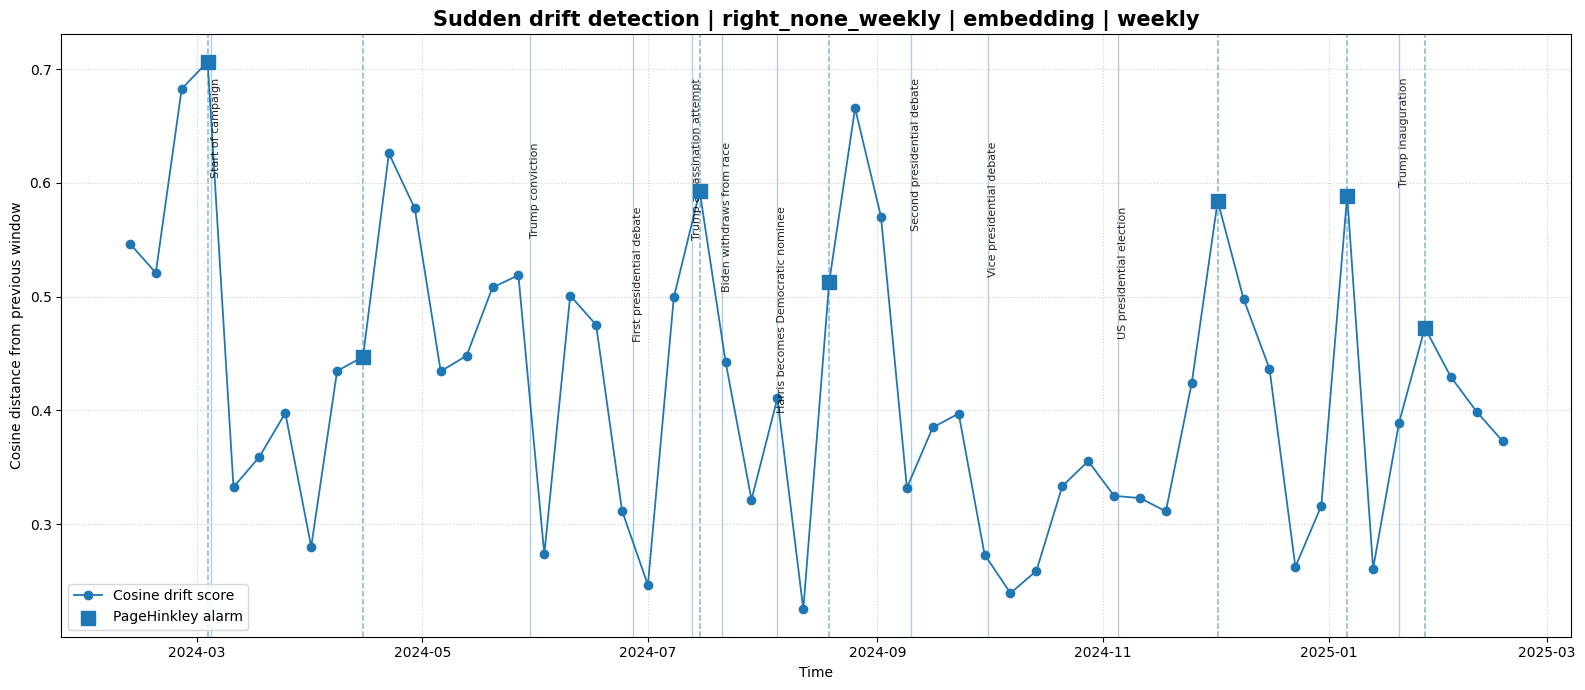

Saved master results in: results\sudden_drift_detection

Errors:


""



Top summary rows:


,feature_type,stream_group,stream_source,stream_family,sampling,detector,time_window_code,time_window_name,detections,true_positives,false_positives,precision_like,avg_delay_days,events_detected,events_missed,event_recall
10,tfidf,mixed_raw_daily,mixed_raw,mixed,raw,PageHinkley,D,daily,33,14,19,0.424242,0.928571,10,0,1.0
25,embedding,mixed_max3_per_class_day_daily,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,D,daily,25,11,14,0.440000,-1.636364,9,1,0.9
28,embedding,mixed_raw_daily,mixed_raw,mixed,raw,PageHinkley,D,daily,36,12,24,0.333333,-0.500000,9,1,0.9
61,embedding,mixed_max3_per_class_day_weekly,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,W,weekly,9,8,1,0.888889,1.375000,8,2,0.8
16,tfidf,right_none_daily,right_none,right,none,PageHinkley,D,daily,31,12,19,0.387097,-0.666667,8,2,0.8
34,embedding,right_none_daily,right_none,right,none,PageHinkley,D,daily,33,12,21,0.363636,-1.166667,8,2,0.8
31,embedding,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,D,daily,31,11,20,0.354839,0.272727,8,2,0.8
13,tfidf,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,D,daily,24,8,16,0.333333,1.625000,8,2,0.8
22,embedding,mixed_global_undersampled_daily,mixed_global_undersampled,mixed,global_undersampled,PageHinkley,D,daily,18,7,11,0.388889,-1.000000,7,3,0.7
67,embedding,mixed_split_minority_day_weekly,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,W,weekly,9,6,3,0.666667,-2.833333,6,4,0.6


In [16]:
raw_df = load_jsonl(INPUT_FILE)
print_dataset_overview(raw_df)

all_scores, all_detections, all_matched, all_summary, errors = run_all_experiments(raw_df)

print("\nErrors:")
display(errors)

print("\nTop summary rows:")
if not all_summary.empty:
    display(
        all_summary
        .sort_values(
            ["event_recall", "precision_like", "true_positives", "detections"],
            ascending=False,
            na_position="last",
        )
        .head(30)
    )
else:
    print("No summary rows generated.")


## Useful post-analysis views

In [17]:
# Best detector/stream combinations by event recall.
if not all_summary.empty:
    best_by_recall = (
        all_summary
        .sort_values(
            ["event_recall", "precision_like", "true_positives", "false_positives"],
            ascending=[False, False, False, True],
            na_position="last",
        )
        .reset_index(drop=True)
    )

    display(best_by_recall.head(50))

    best_by_recall.to_csv(OUTPUT_DIR / "best_by_event_recall.csv", index=False)


,feature_type,stream_group,stream_source,stream_family,sampling,detector,time_window_code,time_window_name,detections,true_positives,false_positives,precision_like,avg_delay_days,events_detected,events_missed,event_recall
0,tfidf,mixed_raw_daily,mixed_raw,mixed,raw,PageHinkley,D,daily,33,14,19,0.424242,0.928571,10,0,1.0
1,embedding,mixed_max3_per_class_day_daily,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,D,daily,25,11,14,0.440000,-1.636364,9,1,0.9
2,embedding,mixed_raw_daily,mixed_raw,mixed,raw,PageHinkley,D,daily,36,12,24,0.333333,-0.500000,9,1,0.9
3,embedding,mixed_max3_per_class_day_weekly,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,W,weekly,9,8,1,0.888889,1.375000,8,2,0.8
4,tfidf,right_none_daily,right_none,right,none,PageHinkley,D,daily,31,12,19,0.387097,-0.666667,8,2,0.8
5,embedding,right_none_daily,right_none,right,none,PageHinkley,D,daily,33,12,21,0.363636,-1.166667,8,2,0.8
6,embedding,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,D,daily,31,11,20,0.354839,0.272727,8,2,0.8
7,tfidf,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,D,daily,24,8,16,0.333333,1.625000,8,2,0.8
8,embedding,mixed_global_undersampled_daily,mixed_global_undersampled,mixed,global_undersampled,PageHinkley,D,daily,18,7,11,0.388889,-1.000000,7,3,0.7
9,embedding,mixed_split_minority_day_weekly,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,W,weekly,9,6,3,0.666667,-2.833333,6,4,0.6


In [18]:
# Event-level matched detections.
if not all_matched.empty:
    matched_only = all_matched[all_matched["is_true_positive"]].copy()
    display(
        matched_only
        .sort_values(["matched_event", "feature_type", "time_window_name", "stream_group", "detector"])
        .head(100)
    )

    matched_only.to_csv(OUTPUT_DIR / "matched_true_positive_detections.csv", index=False)


,feature_type,stream_group,stream_source,stream_family,sampling,detector,time_window,time_window_code,time_window_name,drift_score,matched_event,delay_days,is_true_positive
167,embedding,mixed_max3_per_class_day_daily,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,2024-07-23,D,daily,0.854246,Biden withdraws from race,2.0,True
202,embedding,mixed_raw_daily,mixed_raw,mixed,raw,PageHinkley,2024-07-23,D,daily,0.655955,Biden withdraws from race,2.0,True
237,embedding,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,2024-07-23,D,daily,0.635919,Biden withdraws from race,2.0,True
21,tfidf,mixed_max3_per_class_day_daily,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,2024-07-25,D,daily,0.976574,Biden withdraws from race,4.0,True
45,tfidf,mixed_raw_daily,mixed_raw,mixed,raw,KSWIN,2024-07-23,D,daily,0.514128,Biden withdraws from race,2.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,embedding,mixed_split_minority_day_daily,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,2024-05-28,D,daily,0.627542,Trump conviction,-2.0,True
271,embedding,right_none_daily,right_none,right,none,PageHinkley,2024-05-26,D,daily,0.647334,Trump conviction,-4.0,True
332,embedding,mixed_max3_per_class_day_weekly,mixed_max3_per_class_day,mixed,max3_per_class_day,PageHinkley,2024-06-03,W,weekly,0.726498,Trump conviction,4.0,True
348,embedding,mixed_split_minority_day_weekly,mixed_split_minority_day,mixed,split_minority_day,PageHinkley,2024-05-27,W,weekly,0.634063,Trump conviction,-3.0,True
